# 1. General Information

## 1.1 Domain and problem setting

Madrid is Spain's largest residential property market and one of the most
active in southern Europe. Sale prices in this dataset vary by more than
orders of magnitude, from roughly €36 k for the cheapest listing to €8.8 M
for the most expensive: the same
square-metre footprint can be priced very differently in San Cristóbal
(Villaverde) and Recoletos (Salamanca). Capturing this structure is what
makes valuation hard and what makes it valuable.

Reliable price estimates matter to several stakeholders:

- **Buyers and sellers** -> to negotiate from an evidence-based reference
  rather than a single appraiser's judgement.
- **Mortgage lenders** -> to underwrite loan-to-value ratios consistently
  across thousands of applications.
- **Investment funds and listing portals** -> to value portfolios and
  surface pricing anomalies at scale.

Traditional in-person appraisal is accurate but slow, expensive, and prone
to inter-appraiser variance. A data-driven alternative exploits the
information already present in 21,742 historical listings across Madrid's
21 districts: structural attributes (`sq_mt_built`, `n_rooms`,
`n_bathrooms`, `built_year`), amenity flags (lift, AC, terrace, pool,
accessibility), orientation, and address-derived features (street type,
neighbourhood price index, district encoding).

## 1.2 Research questions

1. Which machine learning algorithm achieves the best regression performance
   on this task?
2. By how much can the best model improve the Linear Regression baseline,
   and where are the trade-offs?

## 1.3 Success criteria

The model is evaluated on:

- **RMSE** — commonly used in machine learning regression task, sensitive to large errors or outliers, making it useful when large errors are undesirable
- **R²** — total variance explained by the feature set (target ≥ 0.80 on the
  OOS test).
- **MAE** — average absolute price error in euros, for stakeholder
  readability.
- **MAPE** — average percentage error (target < 7.5 %, matching the 5–10 %
  range typical of human appraisers, cf. Cho & Megbolugbe 1996).

Baseline = RandomForestRegressor and DecisionForestRegressor with K-fold = 10


# 2. Dataset Description and Collection

## 2.1 Source and collection

Dataset: *Madrid Real Estate Market*, scraped from Idealista and Fotocasa
(the two most popular Spanish property portals), it is dated from 2020, the data was gathered in 18 days from 03/10/2020 - 03/28/2020 being and retrieved via the Kaggle
API.

## 2.2 Initial inspection

- 21,742 listings × 58 raw columns.
- Target: `buy_price` — 100 % populated, median ≈ €375 k, range €36 k – €8.8 M,
  right-skewed.
- Key predictors: `sq_mt_built` (99.4 % filled), `n_rooms`, `n_bathrooms`,
  `neighborhood_id`, `floor`, `has_lift`, `built_year`, `is_new_development`.
- Dtypes: bool (5), float64 (17), int64 (5), object (20), str (10).
- Memory ≈ 12.8 MB.

The cells below load the raw CSV and inspect the dataframe.


In [2]:
import pandas as pd
import numpy as np


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from scipy import stats
import os

plt.rcParams.update({
    "figure.facecolor":  "#0f0f14",
    "axes.facecolor":    "#16161e",
    "axes.edgecolor":    "#ffffff",
    "axes.labelcolor":   "#ffffff",
    "axes.titlecolor":   "#ffffff",
    "xtick.color":       "#FFFFFF",
    "ytick.color":       "#FFFFFF",
    "grid.color":        "#1e1e2a",
    "grid.linewidth":    0.6,
    "text.color":        "#ffffff",
    "font.family":       "monospace",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

ACCENT   = "#7eb8f7"  
ACCENT2  = "#f7a07e"   
ACCENT3  = "#7ef7b0"   
RED_NEG  = "#f77e7e"
SAVE_DIR = "./plots"
DPI      = 150


def _save(fig, name: str):
    os.makedirs(SAVE_DIR, exist_ok=True)
    path = os.path.join(SAVE_DIR, name)
    fig.savefig(path, dpi=DPI, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"  → saved: {path}")

In [4]:
path_data = "./data/houses_Madrid.csv"

In [5]:
df = pd.read_csv(path_data, index_col=0)

In [6]:
df.describe()

,id,sq_mt_built,sq_mt_useful,n_rooms,n_bathrooms,n_floors,sq_mt_allotment,latitude,longitude,portal,...,rent_price_by_area,buy_price,buy_price_by_area,built_year,are_pets_allowed,is_furnished,is_kitchen_equipped,has_private_parking,has_public_parking,parking_price
count,21742.000000,21616.000000,8228.000000,21742.000000,21726.000000,1437.000000,1432.000000,0.0,0.0,0.0,...,0.0,2.174200e+04,21742.000000,10000.000000,0.0,0.0,0.0,0.0,0.0,7719.000000
mean,10871.500000,146.920892,103.458192,3.005749,2.091687,3.128740,241.692737,NaN,NaN,NaN,...,NaN,6.537356e+05,4020.523871,1970.046400,NaN,NaN,NaN,NaN,NaN,2658.000518
std,6276.519112,134.181865,88.259192,1.510497,1.406992,0.907713,247.484853,NaN,NaN,NaN,...,NaN,7.820821e+05,1908.418774,69.386705,NaN,NaN,NaN,NaN,NaN,13360.966258
min,1.000000,13.000000,1.000000,0.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,...,NaN,3.600000e+04,447.000000,1723.000000,NaN,NaN,NaN,NaN,NaN,0.000000
25%,5436.250000,70.000000,59.000000,2.000000,1.000000,2.000000,2.000000,NaN,NaN,NaN,...,NaN,1.980000e+05,2551.000000,1957.000000,NaN,NaN,NaN,NaN,NaN,0.000000
50%,10871.500000,100.000000,79.000000,3.000000,2.000000,3.000000,232.000000,NaN,NaN,NaN,...,NaN,3.750000e+05,3720.000000,1970.000000,NaN,NaN,NaN,NaN,NaN,0.000000
75%,16306.750000,162.000000,113.000000,4.000000,2.000000,4.000000,354.000000,NaN,NaN,NaN,...,NaN,7.636000e+05,5000.000000,1994.000000,NaN,NaN,NaN,NaN,NaN,0.000000
max,21742.000000,999.000000,998.000000,24.000000,16.000000,7.000000,997.000000,NaN,NaN,NaN,...,NaN,8.800000e+06,18889.000000,8170.000000,NaN,NaN,NaN,NaN,NaN,600000.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21742 entries, 0 to 21741
Data columns (total 57 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            21742 non-null  int64  
 1   title                         21742 non-null  str    
 2   subtitle                      21742 non-null  str    
 3   sq_mt_built                   21616 non-null  float64
 4   sq_mt_useful                  8228 non-null   float64
 5   n_rooms                       21742 non-null  int64  
 6   n_bathrooms                   21726 non-null  float64
 7   n_floors                      1437 non-null   float64
 8   sq_mt_allotment               1432 non-null   float64
 9   latitude                      0 non-null      float64
 10  longitude                     0 non-null      float64
 11  raw_address                   16277 non-null  str    
 12  is_exact_address_hidden       21742 non-null  bool   
 13  street_name 

In [8]:
N = len(df)
df.isnull().sum()/N

id                              0.000000
title                           0.000000
subtitle                        0.000000
sq_mt_built                     0.005795
sq_mt_useful                    0.621562
n_rooms                         0.000000
n_bathrooms                     0.000736
n_floors                        0.933907
sq_mt_allotment                 0.934137
latitude                        1.000000
longitude                       1.000000
raw_address                     0.251357
is_exact_address_hidden         0.000000
street_name                     0.271594
street_number                   0.710238
portal                          1.000000
floor                           0.119906
is_floor_under                  0.053813
door                            1.000000
neighborhood_id                 0.000000
operation                       0.000000
rent_price                      0.000000
rent_price_by_area              1.000000
is_rent_price_known             0.000000
buy_price       

array([[<Axes: title={'center': 'sq_mt_built'}>,
        <Axes: title={'center': 'sq_mt_useful'}>,
        <Axes: title={'center': 'n_rooms'}>,
        <Axes: title={'center': 'n_bathrooms'}>,
        <Axes: title={'center': 'n_floors'}>],
       [<Axes: title={'center': 'sq_mt_allotment'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'portal'}>,
        <Axes: title={'center': 'door'}>],
       [<Axes: title={'center': 'rent_price'}>,
        <Axes: title={'center': 'rent_price_by_area'}>,
        <Axes: title={'center': 'buy_price'}>,
        <Axes: title={'center': 'buy_price_by_area'}>,
        <Axes: title={'center': 'built_year'}>],
       [<Axes: title={'center': 'are_pets_allowed'}>,
        <Axes: title={'center': 'is_furnished'}>,
        <Axes: title={'center': 'is_kitchen_equipped'}>,
        <Axes: title={'center': 'has_private_parking'}>,
        <Axes: title={'center': 'has_public_parking'}>

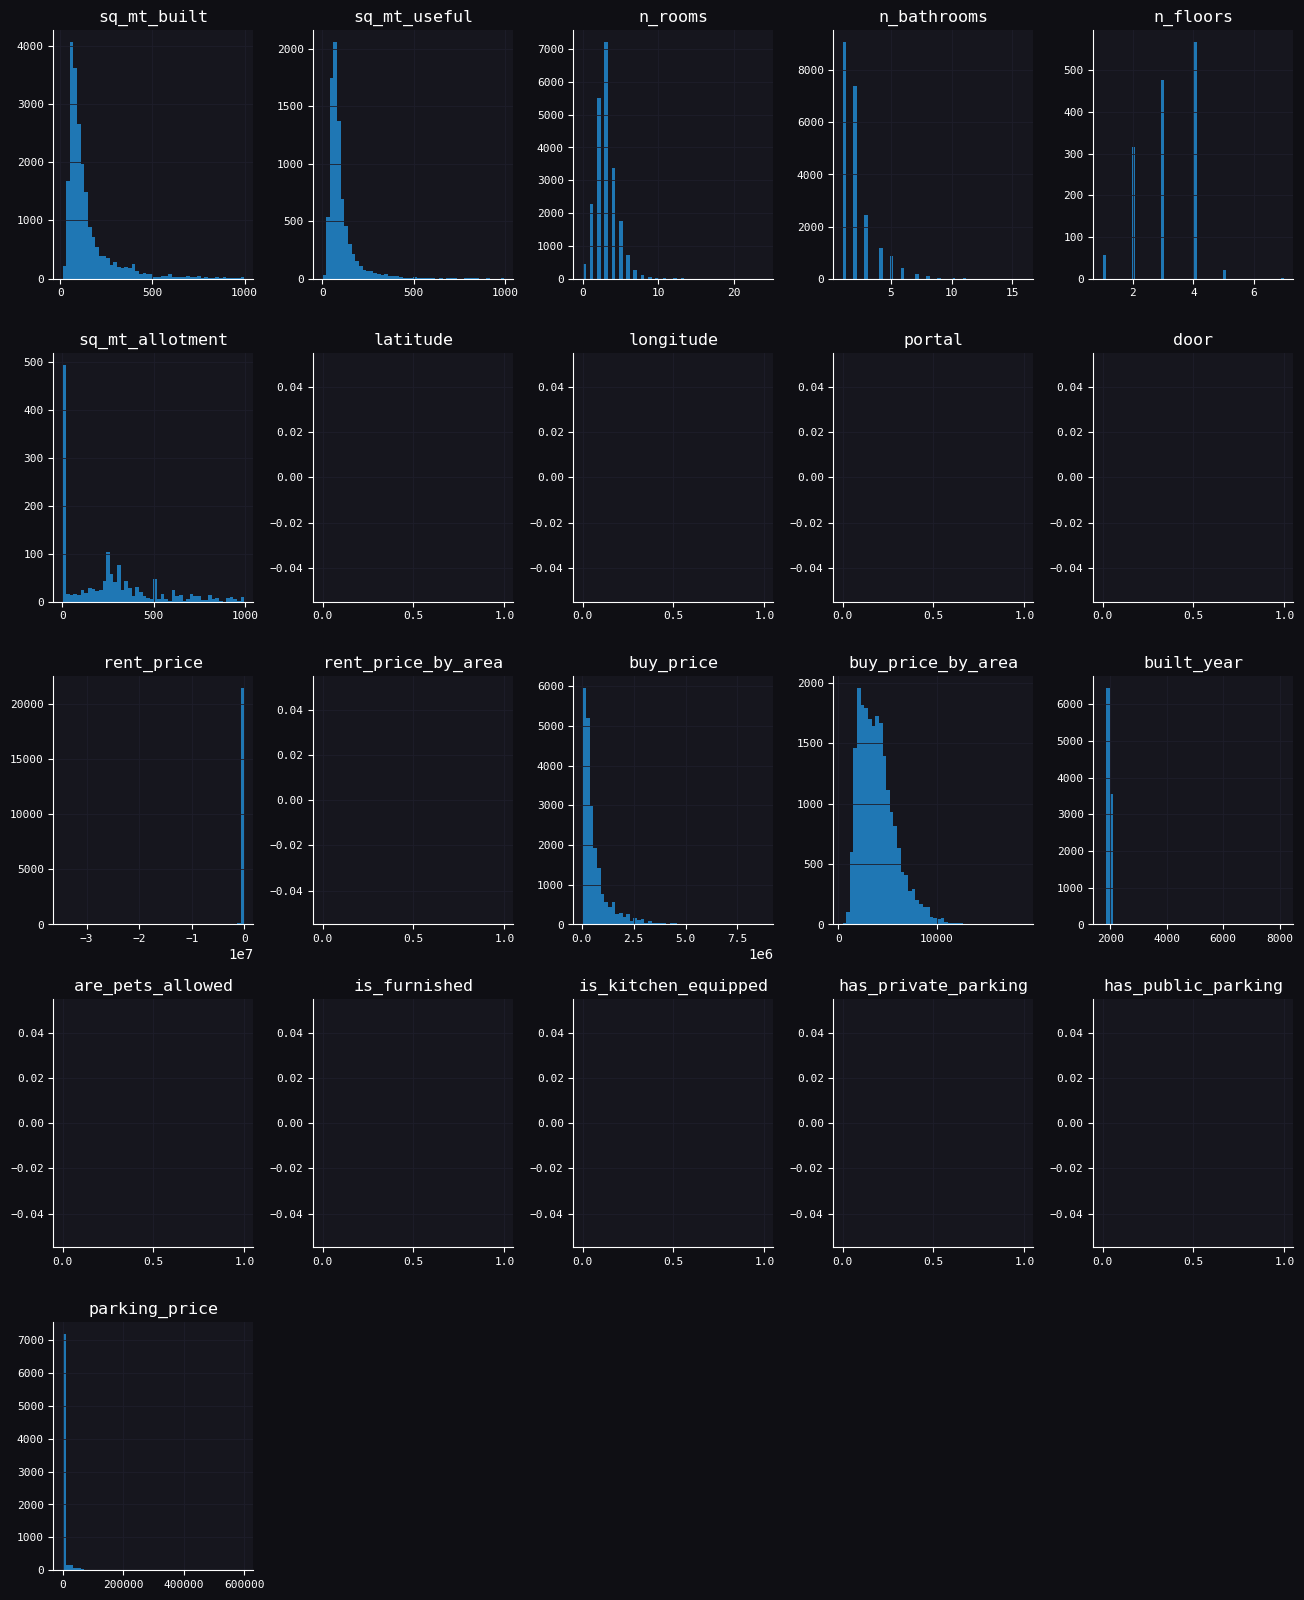

In [9]:
df_num = df.select_dtypes(include = ['float64', 'int64'])
df_num.drop(columns="id", inplace=True, errors="ignore")
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

# 3. Data Analysis

This section runs the pipeline: pre-split preprocessing (cleaning
and feature engineering that depends only on the row itself), train/test
split, post-split preprocessing (fit on train only), model training, and
evaluation.

## 3.1 Pre-split preprocessing

Why pre-split: every transformation here is deterministic and depends only on
the row itself or on fixed domain constants, so it is safe to apply before
the train/test split (no information leaks from test to train).

Helper functions defined below:

- **`curate_df`** — drop columns whose missing ratio exceeds a configurable
  threshold.
- **`filter_built_year`** — remove rows with implausible construction years
  (Madrid's modern cadastral records start ≈ 1850).
- **`fill_amenities`** — impute boolean amenity flags using the `False` (explaination in the report). Amenity prevalence is
  strongly era-dependent (lifts, AC, accessibility all surged at different
  decades), so an unconditional `fillna(False)` would bias older buildings.
- **`fill_orientation`** — mode-fill `is_orientation_*` flags. Missing values
  are data-collection gaps, not absence of orientation.
- **`encode_address`** — extract structured features (street type, number
  flag) from the raw address string.
- **`encode_neighborhood`** — parse `neighborhood_id` into `neighborhood_num`,
  `neighborhood_price_m2` (local price index), `neighborhood_rank` (ordinal),
  and one-hot district name columns.
- **`clean_feature_names`** — strip illegal characters from feature names so
  LightGBM accepts them later in the modelling section.
- **`prepare`** — drop administrative / leakage / redundant raw columns,
  remove rows missing core features, then split into `X` and target `y`.
- **`run_pipeline`** — orchestrator that runs the above in the recommended
  order and returns `(X, y)`.


In [10]:
AMENITY_COLS = [
    "has_ac", 
    "has_fitted_wardrobes",
    "has_lift",
    "is_exterior",
    "has_pool",
    "has_terrace",
    "has_garden",
    "has_balcony",
    "has_storage_room",
    "is_accessible",
    "has_green_zones",
    "has_central_heating",
]
 
ORIENTATION_COLS = [
    "is_orientation_north",
    "is_orientation_south",
    "is_orientation_east",
    "is_orientation_west",
]
 
REFERENCE_DUMMIES = ["house_type_id_Misc", "district_id_21"] # prevent perfect multicollinearity

COLS_TO_DROP_FINAL = ["id", "title", "street_name", "street_number", "rent_price", 
                      "buy_price_by_area",      # ← direct leakage: derived from target
                    "is_buy_price_known",     # ← also leakage: flags whether buy_price exists
                    "rent_price_by_area",     # ← also leakage: derived from target
                    "is_rent_price_known",     # ← also leakage: flags whether rent_price exists
                        ]

### Note on target leakage


buy_price_by_area is computed as buy_price / sq_mt_built. You cannot know buy_price before predicting buy_price. The column is physically absent for every new unseen listing. The model you trained has never learned to predict price, it learned to reverse-engineer a number that won't be there.

In [11]:
def curate_df(df: pd.DataFrame, missing_threshold: float = 0.5) -> pd.DataFrame:

    df_copy = df.copy()

    BINARY_SET = {0, 1, True, False}

    def _is_binary(s: pd.Series) -> bool:
        if s.dtype == bool:
            return True
        non_null = s.dropna()
        if non_null.empty:
            return False
        try:
            return set(non_null.unique()).issubset(BINARY_SET)
        except TypeError:          
            return False

    binary_cols     = [c for c in df_copy.columns if _is_binary(df_copy[c])]
    non_binary_cols = [c for c in df_copy.columns if c not in binary_cols]


    missing_mask = df_copy.isna()
    if non_binary_cols:
        missing_mask[non_binary_cols] = (
            missing_mask[non_binary_cols] | (df_copy[non_binary_cols] == 0)
        )

    missing_ratio = missing_mask.sum() / len(df_copy)
    cols_to_drop  = missing_ratio[missing_ratio > missing_threshold].index.tolist()

    if binary_cols:
        print(f"[curate_df] Protected {len(binary_cols)} binary column(s) "
              f"(0s treated as 'no', not 'missing'):")
        for col in binary_cols:
            print(f"  • {col}")

    if cols_to_drop:
        print(f"[curate_df] Dropping {len(cols_to_drop)} columns "
              f"(>{missing_threshold*100:.0f}% missing):")
        for col in cols_to_drop:
            print(f"  • {col}: {missing_ratio[col]*100:.1f}% missing")
    else:
        print(f"[curate_df] No columns exceed "
              f"{missing_threshold*100:.0f}% missing threshold.")

    df_out = df_copy.drop(columns=cols_to_drop)
    print(f"[curate_df] Shape: {df.shape} → {df_out.shape}\n")
    return df_out


In [12]:
def filter_built_year(df: pd.DataFrame,
                      min_year: int = 1850,
                      max_year: int | None = 2022) -> pd.DataFrame:

    if "built_year" not in df.columns:
        print("[filter_built_year] 'built_year' column not found — skipping.")
        return df.copy()
 
    if max_year is None:
        max_year = pd.Timestamp.now().year
 
    df_copy  = df.copy()
    original = len(df_copy)
 
    # Rows where built_year is recorded but outside valid range
    has_year    = df_copy["built_year"].notna()
    valid_range = df_copy["built_year"].between(min_year, max_year)
    mask_keep   = (~has_year) | valid_range          # keep NaN OR valid
 
    df_out  = df_copy[mask_keep]
    dropped = original - len(df_out)
 
    print(f"[filter_built_year] Removed {dropped} rows with "
          f"built_year outside [{min_year}, {max_year}].")
    print(f"[filter_built_year] Shape: {df.shape} → {df_out.shape}\n")
    
    return df_out

### Why `fillna(False)` instead of cohort-mode imputation

The raw `houses_Madrid.csv` was scraped from Idealista, where each row is a
**sales advertisement** — listings function as marketing material in a
premium real-estate market. The economic incentive is therefore asymmetric:

- An amenity that **exists** is almost always listed, because it justifies a
  higher asking price (pool, garden, terrace, AC, fitted wardrobes, …).
- An amenity that is **absent** is simply not mentioned. The portal has no
  UI for "this apartment has no pool"; the seller has no reason to record it.

Inspection of the raw values confirms this: 9 of the 12 amenity columns
(`has_pool`, `has_garden`, `has_balcony`, `has_storage_room`,
`is_accessible`, `has_green_zones`, `has_terrace`, `has_ac`,
`has_fitted_wardrobes`) contain **zero `False` rows**. The data only ever
records `True` or empty. Under those semantics, "empty" is the implicit
negative class, not a missing measurement.

We therefore replace the original cohort-mode imputation with
`fillna(False)` across all amenity columns (function below). Mode
imputation on a True-or-empty distribution would compute mode = `True` and
flip every empty cell to `True` — producing the failure mode we observed
pre-fix, where post-pipeline `has_pool_True` was `1` for every one of the
21,594 surviving rows even though the raw CSV had only 5,171 True listings.

The three columns with genuine `False` rows in the source (`has_lift`,
`is_exterior`, `has_central_heating`) are treated the same way for
consistency. The marketing-material reading still applies: a building with
a lift, or one explicitly classified as exterior, would advertise it; an
unlisted entry is closer to "amenity not present" than to "we don't know".


In [13]:
def fill_amenities(df: pd.DataFrame,
                           amenity_cols: list[str] | None = None) -> pd.DataFrame:
    
    if amenity_cols is None:
        amenity_cols = AMENITY_COLS
 
    df_copy = df.copy()
    present_cols = [c for c in amenity_cols if c in df_copy.columns]
 
    if not present_cols:
        print("No amenity columns found — skipping.")
        return df_copy
 
    # Fill all missing amenities with False
    filled_count = 0
    for col in present_cols:
        n_filled = df_copy[col].isna().sum()
        if n_filled > 0:
            df_copy[col] = df_copy[col].fillna(False)
            filled_count += n_filled
            print(f"  {col}: filled {n_filled} NaNs with False")
    
    print(f"Filled {filled_count} total NaNs "
          f"across {len(present_cols)} amenity columns.\n")
    return df_copy

In [14]:
def fill_orientation(df: pd.DataFrame,
                     orientation_cols: list[str] | None = None) -> pd.DataFrame:
    
    if orientation_cols is None:
        orientation_cols = ORIENTATION_COLS
 
    df_copy      = df.copy()
    present_cols = [c for c in orientation_cols if c in df_copy.columns]
 
    for col in present_cols:
        if df_copy[col].isna().any():
            mode_val = df_copy[col].mode()
            fill_val = mode_val[0] if not mode_val.empty else False
            n_filled = df_copy[col].isna().sum()
            df_copy[col] = df_copy[col].fillna(fill_val)
            print(f"[fill_orientation] {col}: filled {n_filled} NaNs with '{fill_val}'")
 
    return df_copy
 

In [15]:
import re

def encode_address(df: pd.DataFrame,
                   col: str = "raw_address") -> pd.DataFrame:

    df = df.copy()
    addr = df[col].fillna("").str.strip()

    street_type = addr.str.extract(
        r"^(Calle|Avenida|Paseo|Plaza|Carretera|Camino|Cuesta|Ronda|"
        r"Glorieta|Travesía|Callejón|Sector|Urbanización|Vía)",
        flags=re.IGNORECASE
    )[0].str.title().fillna("Other")

    df["addr_street_type"] = street_type   

    df["addr_has_number"] = addr.str.contains(
        r",?\s*\d+", regex=True
    ).astype(int)

    number = addr.str.extract(r",\s*(\d+)")[0].astype(float)
    df["addr_number_bucket"] = pd.cut(
        number,
        bins=[0, 10, 30, 60, 100, np.inf],
        labels=[1, 2, 3, 4, 5]         
    ).astype(float).fillna(0)           
    df.drop(columns=[col], inplace=True, errors="ignore")
    return df

In [16]:
import re

def clean_feature_names(X: pd.DataFrame) -> pd.DataFrame:

    X = X.copy()
    X.columns = [
        re.sub(r"_+", "_",              
        re.sub(r"[^A-Za-z0-9_]", "_",  
        col)).strip("_")
        for col in X.columns
    ]
    return X

In [17]:
def prepare(df: pd.DataFrame,
            devmode: bool = False,
            cols_to_drop: list[str] | None = None,
            reference_dummies: list[str] | None = None) -> tuple[pd.DataFrame, pd.Series]:


    if cols_to_drop      is None: cols_to_drop      = COLS_TO_DROP_FINAL
    if reference_dummies is None: reference_dummies = REFERENCE_DUMMIES
 
    df = df.copy()
 
    df = df.drop(columns=cols_to_drop, errors="ignore")
    
    df = df.dropna(subset=['sq_mt_built'])
    df = df.dropna(subset=['n_bathrooms'])


    for col in AMENITY_COLS:
        df[col] = df[col].fillna(False)
 
    if "is_new_development" in df.columns:
        df["is_new_development"] = df["is_new_development"].fillna(devmode)
 
    if "house_type_id" in df.columns:
        df["house_type_id"] = df["house_type_id"].fillna("Misc")
 

    if "neighborhood_id" in df.columns:
        # Create district column from neighborhood string before extracting nbhd number
        df["district_id"] = df["neighborhood_id"].str.extract(r"(District \d+)")
        df["district_id"] = df["district_id"].str.extract(r"(\d+)")
        df["neighborhood_id"] = df["neighborhood_id"].str.extract(r"(Neighborhood \d+)")
        df["neighborhood_id"] = df["neighborhood_id"].str.extract(r"(\d+)")


    district_median_year = (
        df.groupby("district_id")["built_year"]
        .median()
        .round()
    )

    df["built_year"] = df["built_year"].fillna(
        df["district_id"].map(district_median_year)
    )

    global_median_year = df["built_year"].median()
    df["built_year"] = df["built_year"].fillna(global_median_year)
 
    df.drop(columns="neighborhood_id", inplace=True, errors="ignore")
 
    df = encode_address(df)

    df = pd.get_dummies(df, drop_first=True, dtype=int)
 
    df = df.drop(columns=reference_dummies, errors="ignore")
 
    # 13. Split X / y
    y = df["buy_price"]
    X = df.drop(columns=["buy_price"])
 
    print(f"[prepare] Final shape — X: {X.shape}, y: {y.shape}")
    return X, y


In [18]:
def run_pre_pipeline(df: pd.DataFrame,
                    ) -> pd.DataFrame:

   print("=" * 60)
   print("Madrid Real Estate — Preprocessing Pipeline")
   print("=" * 60 + "\n")

   df.drop_duplicates(inplace=True)

   return df

In [19]:
def run_post_processing(df, devmode: bool  = False, min_built_year: int   = 1850, missing_threshold: float = 0.60):
    df = fill_orientation(df)
    df = fill_amenities(df)
    df = clean_feature_names(df)
    df = curate_df(df, missing_threshold=missing_threshold)
    X, y = prepare(df, devmode=devmode)

    print("\n" + "=" * 60)
    return X, y

In [20]:
df = run_pre_pipeline(df)

Madrid Real Estate — Preprocessing Pipeline



In [21]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42
)

In [22]:
X_train, y_train = run_post_processing(df_train)
X_test, y_test = run_post_processing(df_test)

[fill_orientation] is_orientation_north: filled 8309 NaNs with 'False'
[fill_orientation] is_orientation_south: filled 8309 NaNs with 'True'
[fill_orientation] is_orientation_east: filled 8309 NaNs with 'False'
[fill_orientation] is_orientation_west: filled 8309 NaNs with 'False'
  has_ac: filled 8431 NaNs with False
  has_fitted_wardrobes: filled 6646 NaNs with False
  has_lift: filled 1875 NaNs with False
  is_exterior: filled 2405 NaNs with False
  has_pool: filled 13286 NaNs with False
  has_terrace: filled 9789 NaNs with False
  has_garden: filled 16181 NaNs with False
  has_balcony: filled 14733 NaNs with False
  has_storage_room: filled 11259 NaNs with False
  is_accessible: filled 14102 NaNs with False
  has_green_zones: filled 14167 NaNs with False
  has_central_heating: filled 6493 NaNs with False
Filled 119367 total NaNs across 12 amenity columns.

[curate_df] Protected 25 binary column(s) (0s treated as 'no', not 'missing'):
  • is_exact_address_hidden
  • is_floor_under
  

In [23]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.01, random_state=42)

model.fit(X_train)
predictions = model.predict(X_train)
scores = model.decision_function(X_train)


In [24]:
indices = np.argsort(scores)[:50]

In [25]:
(X_train.index == 9488).sum()

np.int64(1)

In [26]:
X_train.drop(index=indices.tolist(), inplace=True, errors='ignore')
y_train.drop(index=indices.tolist(), inplace=True, errors='ignore')

In [27]:
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

### Post-pipeline inspection

Sanity-check the prepared feature matrix `X`: confirm no remaining NaNs and
inspect the first rows.


In [28]:
X_train.head(500)

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_renewal_needed,built_year,has_parking,addr_has_number,addr_number_bucket,"subtitle_Abrantes, Madrid",...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
1947,78.0,3,1.0,True,False,1960.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
21382,169.0,3,2.0,True,False,2000.0,True,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
2225,30.0,0,1.0,True,False,1978.0,True,0,0.0,0,...,1,0,0,0,0,0,0,0,0,0
5201,74.0,3,1.0,False,False,1975.0,False,1,2.0,0,...,1,0,0,0,0,0,0,0,0,0
15566,180.0,3,3.0,True,False,2001.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3314,77.0,2,2.0,True,False,1970.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
12827,75.0,3,1.0,True,False,1966.0,False,0,0.0,0,...,1,0,0,0,0,0,0,0,0,0
16409,76.0,3,1.0,True,False,1969.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
16417,51.0,2,1.0,True,True,1965.0,False,0,0.0,0,...,1,0,0,0,0,0,0,0,0,0


In [29]:
len(X_train)

17246

In [30]:
X_train.isna().sum()

sq_mt_built                  0
n_rooms                      0
n_bathrooms                  0
is_exact_address_hidden      0
is_renewal_needed            0
                            ..
addr_street_type_Other       0
addr_street_type_Paseo       0
addr_street_type_Plaza       0
addr_street_type_Ronda       0
addr_street_type_Travesía    0
Length: 230, dtype: int64

## 3.2 Exploratory data analysis (post-cleaning)

Two diagnostic plots on the prepared `(X, y)`:

- **Target distribution + log-transform check** -> confirms the right-skew of
  `buy_price` and motivates the `np.log1p(y)` transform applied at split
  time.

The plotting functions are defined inside the leading docstring of the next
cell (cell 21); cell 22 actually calls them.


In [31]:
def plot_target_distribution(y: pd.Series, save: bool = False) -> plt.Figure:

    y_clean   = np.expm1(y_train).dropna()
    y_log     = np.log1p(y_clean)

    skew_raw  = float(stats.skew(y_clean))
    kurt_raw  = float(stats.kurtosis(y_clean))
    skew_log  = float(stats.skew(y_log))
    kurt_log  = float(stats.kurtosis(y_log))

    sample    = y_clean.sample(min(5000, len(y_clean)), random_state=42)
    _, p_raw  = stats.shapiro(sample)
    _, p_log  = stats.shapiro(np.log1p(sample))

    fig = plt.figure(figsize=(18, 10), facecolor="#0f0f14")
    fig.suptitle("Plot 1 — Target Variable Diagnostics: buy_price",
                 fontsize=15, fontweight="bold", color="#e8e8f0", y=0.98)

    gs   = gridspec.GridSpec(2, 3, figure=fig,
                             hspace=0.45, wspace=0.35,
                             left=0.06, right=0.97, top=0.92, bottom=0.08)
    axA  = fig.add_subplot(gs[0, 0])
    axB  = fig.add_subplot(gs[0, 1])

    # ── A: Raw histogram ────────────────────────────────────────────────────
    n_bins = min(120, int(np.sqrt(len(y_clean)) * 2))
    axA.hist(y_clean / 1e6, bins=n_bins, color=ACCENT, alpha=0.75,
             edgecolor="#0f0f14", linewidth=0.3)
    mu, sd = y_clean.mean() / 1e6, y_clean.std() / 1e6
    xr = np.linspace(y_clean.min() / 1e6, np.percentile(y_clean, 99) / 1e6, 300)
    axA.plot(xr, stats.norm.pdf(xr, mu, sd) * len(y_clean) * (y_clean.max() - y_clean.min()) / (n_bins * 1e6),
             color=ACCENT2, lw=1.8, label="Normal fit")
    axA.set_xlabel("buy_price (M€)")
    axA.set_title("Raw — buy_price", fontsize=11)
    axA.text(0.97, 0.92, f"skew = {skew_raw:.2f}\nkurt = {kurt_raw:.2f}\np_SW = {p_raw:.2e}",
             transform=axA.transAxes, ha="right", va="top",
             fontsize=8.5, color=ACCENT2,
             bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4))
    axA.legend(fontsize=8)
    axA.grid(True, axis="y")

    # ── B: Log histogram ─────────────────────────────────────────────────────
    axB.hist(y_log, bins=n_bins, color=ACCENT3, alpha=0.75,
             edgecolor="#0f0f14", linewidth=0.3)
    mu_l, sd_l = y_log.mean(), y_log.std()
    xl = np.linspace(y_log.min(), y_log.max(), 300)
    axB.plot(xl,
             stats.norm.pdf(xl, mu_l, sd_l) * len(y_log) * (y_log.max() - y_log.min()) / n_bins,
             color=ACCENT2, lw=1.8)
    axB.set_xlabel("log1p(buy_price)")
    axB.set_title("Log-transformed — buy_price", fontsize=11)
    axB.text(0.97, 0.92, f"skew = {skew_log:.2f}\nkurt = {kurt_log:.2f}\np_SW = {p_log:.2e}",
             transform=axB.transAxes, ha="right", va="top",
             fontsize=8.5, color=ACCENT2,
             bbox=dict(facecolor="#1e1e2a", edgecolor="none", pad=4))
    axB.grid(True, axis="y")




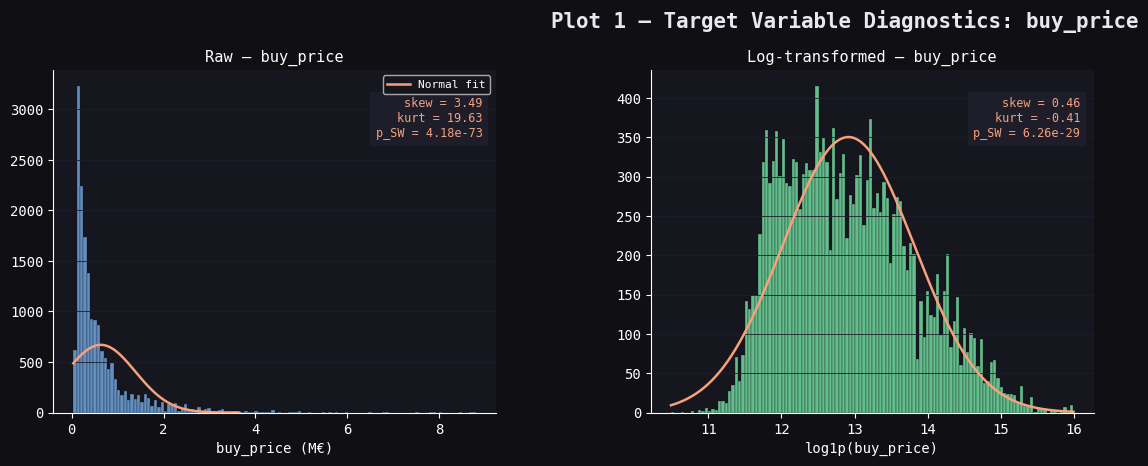

In [32]:
plot_target_distribution(y_train)

In [33]:
from scipy.stats import skew
print(y_train.head())
print(skew(np.expm1x(y_train)))
print(skew(y_train))

1947     11.957618
21382    13.337476
2225     11.918397
5201     12.577640
15566    13.753636
Name: buy_price, dtype: float64
3.4889993808273947
0.46213429555050833


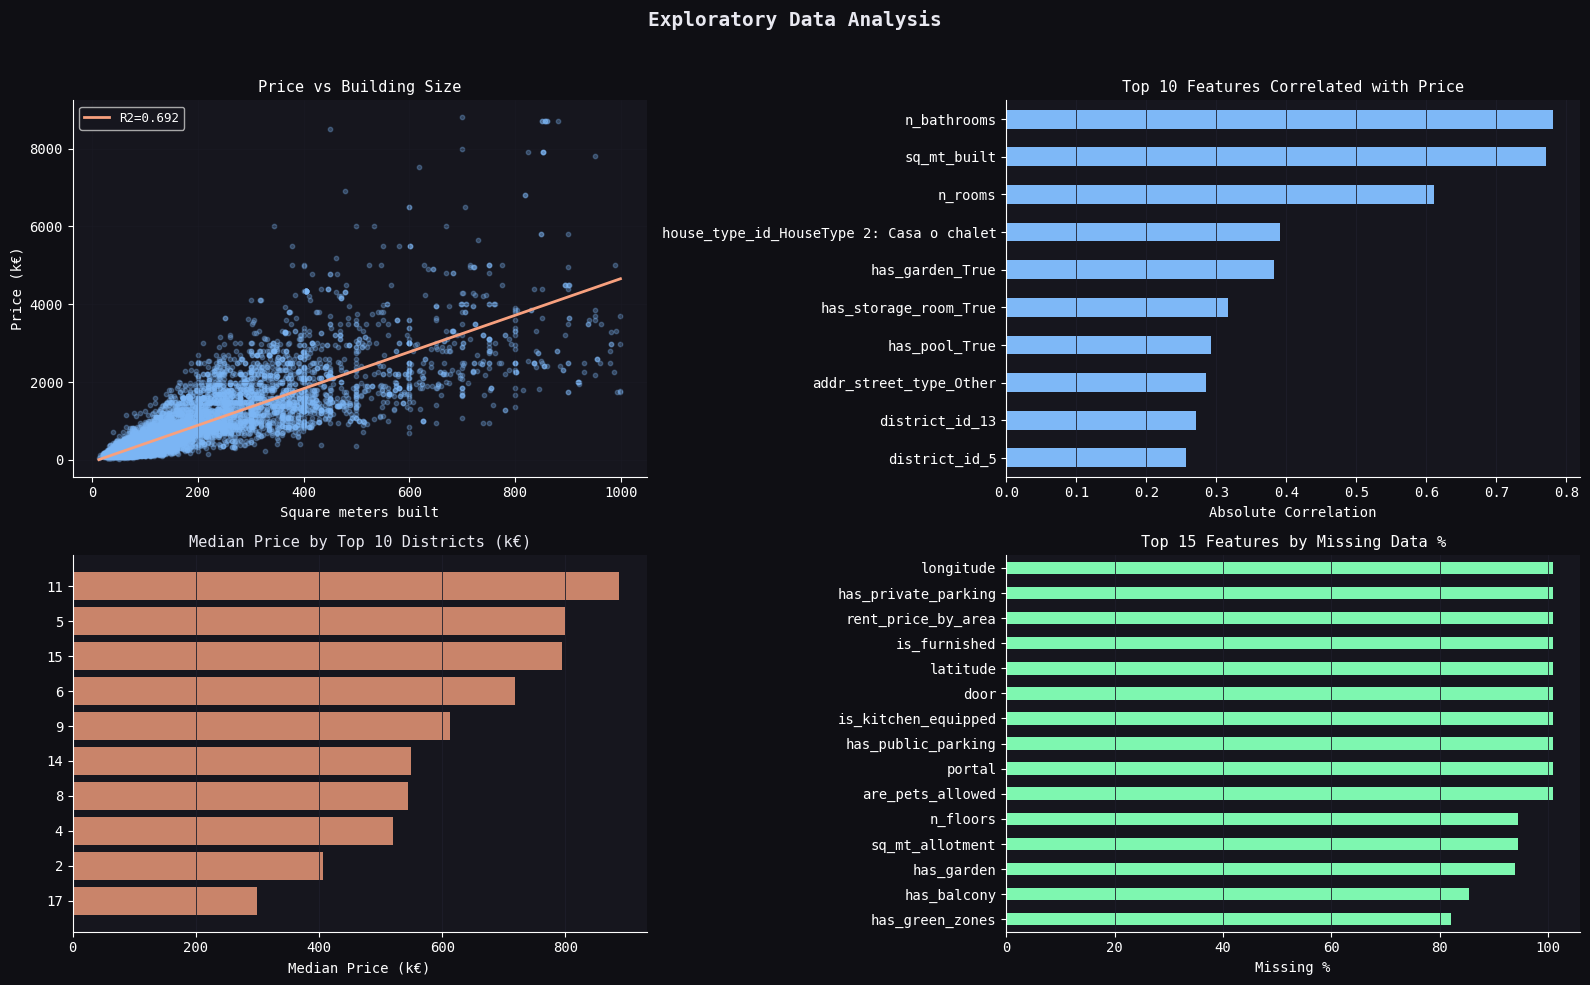

Saved → eda_four_plots.png


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor="#0f0f14")
fig.suptitle("Exploratory Data Analysis",
             fontsize=14, fontweight="bold", color="#e8e8f0")

ax = axes[0, 0]
ax.set_facecolor("#16161e")

if 'sq_mt_built' in X_train.columns:
    sq_mt = X_train['sq_mt_built']
    prices = np.expm1(y_train)
    

    ax.scatter(sq_mt, prices / 1e3, s=10, alpha=0.3, color="#7eb8f7", 
               rasterized=True)

    from scipy.stats import linregress
    valid_mask = ~(sq_mt.isna() | np.isnan(prices))
    slope, intercept, r_value, _, _ = linregress(sq_mt[valid_mask], 
                                                   prices[valid_mask] / 1e3)
    x_line = np.array([sq_mt.min(), sq_mt.max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color="#f7a07e", lw=2, 
            label=f"R2={r_value**2:.3f}")
    
    ax.set_title("Price vs Building Size", fontsize=11, color="#ffffff")
    ax.set_xlabel("Square meters built", color="#FFFFFF")
    ax.set_ylabel("Price (k€)")
    ax.legend(fontsize=9)
    ax.grid(True, color="#1e1e2a", alpha=0.3)
else:
    ax.text(0.5, 0.5, "sq_mt_built not found", ha='center', va='center', 
            color="#888899")

ax = axes[0, 1]
ax.set_facecolor("#16161e")
num_cols = X_train.select_dtypes('number').columns
corr_with_price = pd.Series(
    [X_train[col].corr(y_train) for col in num_cols],
    index=num_cols
).abs().sort_values(ascending=True).tail(10)
corr_with_price.plot(kind='barh', ax=ax, color="#7eb8f7", edgecolor="none")
ax.set_title("Top 10 Features Correlated with Price", fontsize=11, color="#ffffff")
ax.set_xlabel("Absolute Correlation")
ax.grid(True, axis="x", color="#1e1e2a")
 
ax = axes[1, 0]
ax.set_facecolor("#16161e")
district_col = [c for c in X_train.columns if 'district' in c.lower()]
if district_col:
    
    district_prices = []
    for col in sorted(district_col):
        district_name = col.replace('district_id_', '')
        mask = X_train[col] == 1
        if mask.sum() > 10: 
            prices = np.expm1(y_train[mask])
            district_prices.append((district_name, prices.median(), prices.count()))
    
    district_prices.sort(key=lambda x: x[1], reverse=True)
    top_districts = district_prices[:10]
    top_districts.reverse()
    names = [d[0] for d in top_districts]
    medians = [d[1] / 1e3 for d in top_districts]
    
    ax.barh(names, medians, color="#f7a07e", edgecolor="none", alpha=0.8)
    ax.set_title("Median Price by Top 10 Districts (k€)", fontsize=11, color="#e8e8f0")
    ax.set_xlabel("Median Price (k€)"); ax.grid(True, axis="x")
else:
    ax.text(0.5, 0.5, "No district data", ha='center', va='center', color="#FFFFFF")
 

ax = axes[1, 1]
ax.set_facecolor("#16161e")
missing_pct = (df_train.isna().sum() / len(X_train) * 100).sort_values(ascending=True).tail(15)
missing_pct.plot(kind='barh', ax=ax, color="#7ef7b0", edgecolor="none")
ax.set_title("Top 15 Features by Missing Data %", fontsize=11, color="#ffffff")
ax.set_xlabel("Missing %"); ax.grid(True, axis="x")
 
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eda_four_plots.png", dpi=150, bbox_inches="tight",
            facecolor="#0f0f14")
plt.show()
 
print("Saved → eda_four_plots.png")

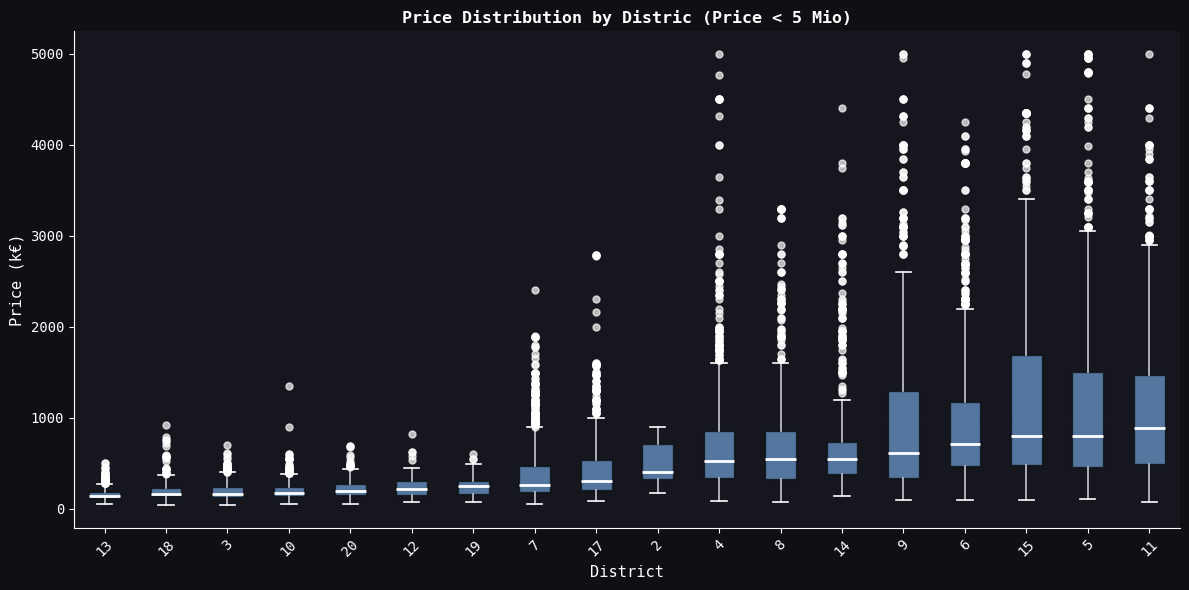

Saved → district_prices_boxplot.png


In [35]:
district_cols = [c for c in X_train.columns if 'district_id_' in c.lower()]

district_data = []
for col in sorted(district_cols):
    district_name = col.replace('district_id_', '')
    mask = X_train[col] == 1
    if mask.sum() > 5:  
        prices = np.expm1(y_train[mask]) / 1e3
        prices = prices[prices <= 5000]  
        district_data.append({
            'district': district_name,
            'prices': prices,
            'median': prices.median(),
        })

# Sort by median price
district_data.sort(key=lambda x: x['median'])

# Create boxplot
fig, ax = plt.subplots(figsize=(12, 6))

districts = [d['district'] for d in district_data]
prices = [d['prices'].values for d in district_data]

bp = ax.boxplot(prices, labels=districts, patch_artist=True, vert=True,
                flierprops=dict(marker='o', markerfacecolor='#ffffff', 
                               markeredgecolor='#ffffff', markersize=5, alpha=0.7))

# Style the boxes
for patch in bp['boxes']:
    patch.set_facecolor("#7eb8f7")
    patch.set_alpha(0.6)

# Style whiskers, caps, medians
for whisker in bp['whiskers']:
    whisker.set(color="#c8c8d4", linewidth=1.2)
for cap in bp['caps']:
    cap.set(color="#ffffff", linewidth=1.2)
for median in bp['medians']:
    median.set(color="#ffffff", linewidth=2)

ax.set_ylabel("Price (k€)", fontsize=11)
ax.set_xlabel("District", fontsize=11)
ax.set_title("Price Distribution by Distric (Price < 5 Mio)", fontsize=12, fontweight="bold")
ax.grid(axis='y', alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("district_prices_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved → district_prices_boxplot.png")

## 3.3 Train/test split and post-split preprocessing

Why this order:

- **`build_pipeline(X_train)`** — Only numeric engenieering for smoother training settings of the non-tree models. No improvement was found on transforming categorical values.

- **`np.log1p(y)`** — the target is right-skewed;
  log-transforming stabilises errors across price segments. Predictions are
  inverted with `np.expm1` before reporting MAE in euros.


In [36]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.preprocessing   import (RobustScaler, PowerTransformer,
                                     StandardScaler, OneHotEncoder)
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition   import PCA
from sklearn.base            import BaseEstimator, TransformerMixin


X_train_num = X_train.select_dtypes('number')
X_test_num  = X_test.select_dtypes('number')
X_test_num = X_test_num.reindex(columns=X_train_num.columns, fill_value=0)

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),      
    ('scaler',  StandardScaler()),
])

X_prepared_train = num_pipeline.fit_transform(X_train_num)
X_prepared_test  = num_pipeline.transform(X_test_num)

print(f"Train shape: {X_prepared_train.shape}, Test shape: {X_prepared_test.shape}")

Train shape: (17246, 227), Test shape: (4313, 227)


In [37]:
from sklearn.preprocessing import TargetEncoder

enc_auto = TargetEncoder(smooth="auto")
X_trans = enc_auto.fit_transform(X_train, y_train)

In [38]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_prepared_train)

pca = PCA(n_components=5) 

X_pca = pca.fit_transform(X_scaled)

In [39]:
X_prepared_train.shape

(17246, 227)

## 3.4 ML algorithms Baseline

Models trained here, all via K-fold cross-validation on the training
partition with per-fit timing:

- **DecisionTreeRegressor + RandomForestRegressor** -> Tree models (with bagging).
- **XGBoost + LightGBM** -> gradient-boosted ensembles. Column names are
  sanitised with a regex (`[^A-Za-z0-9_]+` → ``) so LightGBM accepts them.


In [40]:
X_train.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_renewal_needed,built_year,has_parking,addr_has_number,addr_number_bucket,"subtitle_Abrantes, Madrid",...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Travesía
1947,78.0,3,1.0,True,False,1960.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
21382,169.0,3,2.0,True,False,2000.0,True,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
2225,30.0,0,1.0,True,False,1978.0,True,0,0.0,0,...,1,0,0,0,0,0,0,0,0,0
5201,74.0,3,1.0,False,False,1975.0,False,1,2.0,0,...,1,0,0,0,0,0,0,0,0,0
15566,180.0,3,3.0,True,False,2001.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0


In [41]:
from sklearn.metrics import make_scorer, mean_absolute_error, median_absolute_error, r2_score

def mae_euros(y_true, y_pred):
    return mean_absolute_error(np.expm1(y_true), np.expm1(y_pred))

def medae_euros(y_true, y_pred):
    return median_absolute_error(np.expm1(y_true), np.expm1(y_pred))

def rmse_euros(y_true, y_pred):
    y_true_e = np.expm1(y_true)
    y_pred_e = np.expm1(y_pred)
    return np.sqrt(np.mean((y_true_e - y_pred_e) ** 2))

def mape_pct(y_true, y_pred):
    y_true_e = np.expm1(y_true)
    y_pred_e = np.expm1(y_pred)
    return np.mean(np.abs((y_true_e - y_pred_e) / y_true_e)) * 100

def r2_euros(y_true, y_pred):
    """R² computed on euro scale (back-transformed)."""
    y_true_e = np.expm1(y_true)
    y_pred_e = np.expm1(y_pred)
    return r2_score(y_true_e, y_pred_e)

def median_absolute_percentage_error(y_true, y_pred):
    y_true_e = np.expm1(y_true)
    y_pred_e = np.expm1(y_pred)

    return np.median(np.abs((y_true_e- y_pred_e) / y_true_e)) * 100

scoring = {
    'r2':       "r2",# 'r2',
    'mae':      make_scorer(mae_euros, greater_is_better=False),
    'medae':    make_scorer(medae_euros, greater_is_better=False),
    'rmse':     make_scorer(rmse_euros, greater_is_better=False),
    'mape':     make_scorer(mape_pct, greater_is_better=False),
    "medape":   make_scorer(median_absolute_percentage_error, greater_is_better=False)
}

In [42]:
y_train.head()

1947     11.957618
21382    13.337476
2225     11.918397
5201     12.577640
15566    13.753636
Name: buy_price, dtype: float64

In [43]:
from sklearn import metrics
from sklearn import model_selection
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model     import Ridge, ElasticNet
import xgboost as xgb
import lightgbm as lgb
import math
import time

print(f"{"--" * 60}")
print("Baseline Models")

print(f"{"--" * 60}")

print(f"\n{'='*90}")
print(f"{'Model':<22} {'R²':>7} {'MAE €':>12} {'MedAE €':>12} {'RMSE €':>12} {'MAPE %':>8} {'Time (s)':>10}")
print(f"{'='*90}")

for model in [LinearRegression, Ridge, ElasticNet]:
    start_time = time.perf_counter()
    cls=model()
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
    s = model_selection.cross_validate(
        cls, X_train, y_train,
        scoring=scoring,
        cv=kfold,
        n_jobs=-1
    )
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    
    # Extract and flip signs (scorers negate, so *-1 to get positive)
    r2    = s['test_r2'].mean()
    mae   = -s['test_mae'].mean()
    medae = -s['test_medae'].mean()
    rmse  = -s['test_rmse'].mean()
    mape  = -s['test_mape'].mean()
    
    print(
        f"{model.__name__:<22} {r2:>7.3f} {mae:>11,.0f} {medae:>11,.0f} "
        f"{rmse:>11,.0f} {mape:>7.2f}% {duration:>10.2f}s"
    )

print(f"{'='*90}\n")

------------------------------------------------------------------------------------------------------------------------
Baseline Models
------------------------------------------------------------------------------------------------------------------------

Model                       R²        MAE €      MedAE €       RMSE €   MAPE %   Time (s)
LinearRegression         0.912     163,163      50,390     459,055   20.41%       3.52s
Ridge                    0.912     163,258      50,405     459,806   20.41%       0.33s
ElasticNet               0.617     400,717     130,530   1,607,459   52.16%       0.34s



In [44]:
from sklearn import metrics
from sklearn import model_selection
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import math
import time

print(f"{"--" * 60}")
print("Baseline Models")

print(f"{"--" * 60}")

print(f"\n{'='*90}")
print(f"{'Model':<22} {'R²':>7} {'MAE €':>12} {'MedAE €':>12} {'RMSE €':>12} {'MAPE %':>8} {'Time (s)':>10}")
print(f"{'='*90}")

for model in [DecisionTreeRegressor, RandomForestRegressor]:
    start_time = time.perf_counter()
    cls=model()
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
    s = model_selection.cross_validate(
        cls, X_train, y_train,
        scoring=scoring,
        cv=kfold,
        n_jobs=-1
    )
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    
    # Extract and flip signs (scorers negate, so *-1 to get positive)
    r2    = s['test_r2'].mean()
    mae   = -s['test_mae'].mean()
    medae = -s['test_medae'].mean()
    rmse  = -s['test_rmse'].mean()
    mape  = -s['test_mape'].mean()
    
    print(
        f"{model.__name__:<22} {r2:>7.3f} {mae:>11,.0f} {medae:>11,.0f} "
        f"{rmse:>11,.0f} {mape:>7.2f}% {duration:>10.2f}s"
    )

------------------------------------------------------------------------------------------------------------------------
Baseline Models
------------------------------------------------------------------------------------------------------------------------

Model                       R²        MAE €      MedAE €       RMSE €   MAPE %   Time (s)
DecisionTreeRegressor    0.886     144,886      47,219     347,300   22.22%       0.79s
RandomForestRegressor    0.940     110,880      38,173     257,409   16.21%      29.41s


In [45]:
import regex as re
from sklearn.ensemble         import GradientBoostingRegressor

train_x = X_train.rename(columns = lambda x:re.sub('[^A-Za-z0-9_]+', '', x))
#missing vals included

print(f"\n{'='*90}")
print(f"{'Model':<22} {'R²':>7} {'MAE €':>12} {'MedAE €':>12} {'RMSE €':>12} {'MAPE %':>8} {"MEDAPE %": >8}{'Time (s)':>10}")
print(f"{'='*90}")

for model in [xgb.XGBRegressor, lgb.LGBMRegressor, GradientBoostingRegressor]:
    start_time = time.perf_counter()
    if model == lgb.LGBMRegressor:
        cls=model(force_row_wise=True, verbose=-1)
    else:
        cls=model()
    kfold = model_selection.KFold(n_splits=10, shuffle=True, random_state=42)
    s = model_selection.cross_validate(
        cls, train_x, y_train,
        scoring=scoring,
        cv=kfold,
        n_jobs=-1
    )
    
    end_time = time.perf_counter()
    duration = end_time - start_time
    
    # Extract and flip signs (scorers negate, so *-1 to get positive)
    r2    = s['test_r2'].mean()
    mae   = -s['test_mae'].mean()
    medae = -s['test_medae'].mean()
    rmse  = -s['test_rmse'].mean()
    mape  = -s['test_mape'].mean()
    medape  = -s['test_medape'].mean()
    
    print(
        f"{model.__name__:<22} {r2:>7.3f} {mae:>11,.0f} {medae:>11,.0f} "
        f"{rmse:>11,.0f} {mape:>7.2f}% {medape:>7.2f}% {duration:>10.2f}s"
    )


Model                       R²        MAE €      MedAE €       RMSE €   MAPE % MEDAPE %  Time (s)
XGBRegressor             0.946     111,465      40,210     254,878   15.82%   11.80%       1.17s
LGBMRegressor            0.945     114,162      41,438     259,755   16.05%   12.16%       3.10s
GradientBoostingRegressor   0.916     140,642      55,323     311,751   20.63%   16.25%       6.06s


## 3.5 Feature Importance for a Random Forest model

- **Random-forest feature importance** (impurity-based ranking).


In [46]:
# ── 1. Feature importance — what is the model actually using? ────────────
importances = pd.Series(
    RandomForestRegressor().fit(X_train, y_train).feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Top 15 features by importance:")
print(importances.head(15).to_string())

# ── 3. Pearson correlation with target ───────────────────────────────────
corr = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("\nTop 10 correlations with y_train:")
print(corr.head(10).to_string())

Top 15 features by importance:
sq_mt_built       0.756751
has_lift_True     0.046587
built_year        0.045949
n_bathrooms       0.023009
district_id_5     0.010744
n_rooms           0.006417
district_id_13    0.006310
district_id_3     0.004371
district_id_18    0.003710
district_id_20    0.003131
district_id_19    0.003126
district_id_17    0.003105
district_id_4     0.003074
has_pool_True     0.002767
district_id_15    0.002665

Top 10 correlations with y_train:
n_bathrooms                                 0.780563
sq_mt_built                                 0.771317
n_rooms                                     0.610355
has_parking                                 0.411436
house_type_id_HouseType 2: Casa o chalet    0.390643
has_garden_True                             0.381928
has_storage_room_True                       0.316833
has_pool_True                               0.292369
addr_street_type_Other                      0.284638
district_id_13                              0.271504

R² = 1 - (SS_residual / SS_total)
   = 1 - (sum of squared errors / variance of y) //what fraction of the variance in buy_price does the model explain

## 4 Model selection — nested cross-validation

Structure:

- **Outer loop** — 5 folds (3 in fast mode) for an unbiased estimate of
  generalisation error.
- **Inner loop** — 3 folds (2 in fast mode) with `RandomizedSearchCV` for
  hyper-parameter tuning per outer fold.

`FAST=False` runs the full search; `FAST=True` cuts runtime to ≈ 2–3 min on
a stratified subsample (`FAST_SAMPLE_SIZE=3000`). The winner is printed and
feeds the final fit in §4.3.


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, 
                       message=".*sklearn.utils.parallel.*")

from sklearn.model_selection  import (KFold, RandomizedSearchCV,
                                      cross_val_score, cross_validate)
from sklearn.linear_model     import Ridge, ElasticNet
from sklearn.ensemble         import GradientBoostingRegressor
from sklearn.metrics          import make_scorer, mean_absolute_error, root_mean_squared_error
from sklearn.preprocessing    import RobustScaler, StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.utils.parallel import Parallel, delayed
from sklearn.base import clone
import xgboost  as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd


MODELS_TO_RUN = ["RandomForest", "XGBoost"]  

FAST = True
FAST_SAMPLE_SIZE = 3_000

X_train = clean_feature_names(X_train)
X_test  = clean_feature_names(X_test)

def rmse_euros(y_true, y_pred):
    return root_mean_squared_error(np.expm1(y_true), np.expm1(y_pred))

scorer = make_scorer(rmse_euros, greater_is_better=False)

outer_cv = KFold(n_splits=3 if FAST else 5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=2 if FAST else 3, shuffle=True, random_state=42)

if FAST:
    _idx = (
        pd.qcut(y_train, q=10, labels=False, duplicates="drop")
          .groupby(pd.qcut(y_train, q=10, labels=False, duplicates="drop"))
          .apply(lambda g: g.sample(
              min(len(g), FAST_SAMPLE_SIZE // 10), random_state=42))
          .index.get_level_values(1)
    )
    X_run = X_train.loc[_idx].reset_index(drop=True)
    y_run = y_train.loc[_idx].reset_index(drop=True)
    print(f"[FAST MODE] Using {len(X_run):,} / {len(X_train):,} rows")
else:
    X_run = X_train
    y_run = y_train
    print("[FULL MODE] Using full training set")

MODELS = {
    "Ridge": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  Ridge()),
        ]),
        "params_full": {
            "model__alpha": np.logspace(-2, 4, 50),
        },
        "params_fast": {
            "model__alpha": np.logspace(-1, 3, 10),
        },
        "n_iter": 20,
    },

    "RandomForest": {
        "estimator": RandomForestRegressor(n_jobs=-1),
        "params_full": {
            "n_estimators":     [300, 800],
            "max_depth":        [20, None],
            "min_samples_leaf": [10, 20, None],
            "min_samples_split": [2, 10],
            "max_features":     ["sqrt", "log2", None],
        },
        "params_fast": {
            "n_estimators":     [100, 400],
            "max_depth":        [10, 20, None],
            "min_samples_leaf": [5, 10],
        },
        "n_iter": 15,
    },

    "ElasticNet": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model",  ElasticNet(max_iter=5000)),
        ]),
        "params_full": {
            "model__alpha":    np.logspace(-3, 2, 40),
            "model__l1_ratio": np.linspace(0.1, 0.9, 9),
        },
        "params_fast": {
            "model__alpha":    np.logspace(-2, 1, 8),
            "model__l1_ratio": [0.2, 0.5, 0.8],
        },
        "n_iter": 15,
    },

    "GradientBoosting": {
        "estimator": GradientBoostingRegressor(random_state=42),
        "params_full": {
            "n_estimators":     [200, 400, 600],
            "learning_rate":    [0.01, 0.05, 0.1],
            "max_depth":        [3, 4, 5],
            "subsample":        [0.7, 0.8, 1.0],
            "min_samples_leaf": [10, 20, 30],
        },
        "params_fast": {
            "n_estimators":  [100, 200],
            "learning_rate": [0.05, 0.1],
            "max_depth":     [3, 4],
        },
        "n_iter": 12,
    },

    "XGBoost": {
        "estimator": xgb.XGBRegressor(
            tree_method="hist", random_state=42, n_jobs=-1,
            verbosity=0, eval_metric="mae",
        ),
        "params_full": {
            "n_estimators":     [300, 500, 800],
            "learning_rate":    [0.01, 0.05, 0.1],
            "max_depth":        [4, 5, 6, 7],
            "subsample":        [0.7, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "reg_alpha":        [0, 0.1, 0.5, 1.0],
            "reg_lambda":       [0.5, 1.0, 2.0],
            "min_child_weight": [1, 5, 10],
        },
        "params_fast": {
            "n_estimators":  [200, 400],
            "learning_rate": [0.05, 0.1],
            "max_depth":     [4, 6],
            "reg_alpha":     [0, 0.1],
        },
        "n_iter": 20,
    },

    "LightGBM": {
        "estimator": lgb.LGBMRegressor(
            random_state=42, n_jobs=-1, verbose=-1,
        ),
        "params_full": {
            "n_estimators":      [300, 500, 800],
            "learning_rate":     [0.01, 0.1],
            "max_depth":         [-1, 10],
            "num_leaves":        [63, 127],
            "subsample":         [0.7, 1.0],
            "colsample_bytree":  [0.6, 0.8, 1.0],
            "reg_alpha":         [0, 0.5],
            "reg_lambda":        [0, 0.1, 1.0],
            "min_child_samples": [10, 30],
        },
        "params_fast": {
            "n_estimators":  [200, 400],
            "learning_rate": [0.05, 0.1],
            "num_leaves":    [31, 63],
            "reg_lambda":    [0, 0.1],
        },
        "n_iter": 20,
    },
}

if MODELS_TO_RUN is not None:
    MODELS = {k: v for k, v in MODELS.items() if k in MODELS_TO_RUN}
    print(f"Running only: {', '.join(MODELS.keys())}\n")

mode_label = "FAST" if FAST else "FULL"
outer_n    = 3 if FAST else 5
inner_n    = 2 if FAST else 3

print(f"\n{'═'*70}")
print(f"  Nested CV — Model Selection  [{mode_label} MODE]")
print(f"  Outer: {outer_n}-fold  |  Inner: {inner_n}-fold RandomizedSearch")
if FAST:
    print(f"  Data : {len(X_run):,} rows  |  Narrow param grids  |  Halved n_iter")
print(f"{'═'*70}\n")

summary = []

for name, cfg in MODELS.items():
    params  = cfg["params_fast"] if FAST else cfg["params_full"]
    n_iter  = max(5, cfg["n_iter"] // 2) if FAST else cfg["n_iter"]

    print(f"  ▶ {name:<18} params={len(params)} keys  n_iter={n_iter} … ",
          end="", flush=True)

    search = RandomizedSearchCV(
        estimator           = cfg["estimator"],
        param_distributions = params,
        n_iter              = n_iter,
        cv                  = inner_cv,
        scoring             = scoring,
        refit               = "rmse",
        n_jobs              = -1,
        random_state        = 42,
    )

    outer_scores = cross_validate(
        search, X_train, y_run,
        cv      = outer_cv,
        scoring = scoring,
        n_jobs  = -1,
    )
    
    rmse_scores = -outer_scores['test_rmse']
    mae_scores = -outer_scores['test_mae']
    medae_scores = -outer_scores['test_medae']
    r2_scores = outer_scores['test_r2']
    mape_scores = -outer_scores['test_mape']
    medape_scores = -outer_scores['test_medape']

    search.fit(X_run, y_run)
    best_params = search.best_params_

    summary.append({
        "model":       name,
        "r2_mean":     outer_scores['test_r2'].mean(),
        "r2_std":      outer_scores['test_r2'].std(),
        "mae_mean":    -outer_scores['test_mae'].mean(),
        "mae_std":     outer_scores['test_mae'].std(),
        "medae_mean":  -outer_scores['test_medae'].mean(),
        "medae_std":   outer_scores['test_medae'].std(),
        "rmse_mean":   -outer_scores['test_rmse'].mean(),
        "rmse_std":    outer_scores['test_rmse'].std(),
        "mape_mean":   -outer_scores['test_mape'].mean(),
        "mape_std":    outer_scores['test_mape'].std(),
        "medape_mean": -outer_scores['test_medape'].mean(),
        "medape_std":  outer_scores['test_medape'].std(),
        "best_params": search.best_params_,
    })

    print(f"R²={outer_scores['test_r2'].mean():.3f}  "
          f"RMSE €{-outer_scores['test_rmse'].mean():>8,.0f} ± "
          f"€{outer_scores['test_rmse'].std():>6,.0f}")



summary.sort(key=lambda x: x["rmse_mean"])

print(f"\n{'═'*120}")
print(f"{'Rank':<5} {'Model':<15} {'R²':>8} {'MAE €':>12} {'MedAE €':>12} "
      f"{'RMSE €':>12} {'MAPE %':>10} {'MedAPE %':>10}")
print(f"{'─'*120}")

for rank, row in enumerate(summary, 1):
    print(f"  {rank:<5} {row['model']:<15} "
          f"{row['r2_mean']:>8.3f} "
          f"€{row['mae_mean']:>11,.0f} €{row['medae_mean']:>11,.0f} "
          f"€{row['rmse_mean']:>11,.0f} {row['mape_mean']:>9.2f}% "
          f"{row['medape_mean']:>9.2f}%")

print(f"{'═'*120}\n")

[FAST MODE] Using 3,000 / 17,246 rows
Running only: RandomForest, XGBoost


══════════════════════════════════════════════════════════════════════
  Nested CV — Model Selection  [FAST MODE]
  Outer: 3-fold  |  Inner: 2-fold RandomizedSearch
  Data : 3,000 rows  |  Narrow param grids  |  Halved n_iter
══════════════════════════════════════════════════════════════════════

  ▶ RandomForest       params=3 keys  n_iter=7 … 

/Users/julianlorenz/miniconda3/envs/bigdata/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/julianlorenz/miniconda3/envs/bigdata/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/julianlorenz/miniconda3/envs/bigdata/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/jul

R²=0.883  RMSE € 304,002 ± €22,762
  ▶ XGBoost            params=4 keys  n_iter=10 … R²=0.927  RMSE € 282,653 ± €20,608

════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Rank  Model                 R²        MAE €      MedAE €       RMSE €     MAPE %   MedAPE %
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1     XGBoost            0.927 €    129,053 €     46,587 €    282,653     18.49%     13.98%
  2     RandomForest       0.883 €    149,158 €     63,125 €    304,002     23.83%     17.45%
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════



 ## Statistics of a former run:
  
  ▶ Ridge              params=1 keys  n_iter=20 … MAE € 159,631 ± € 2,041

  ▶ ElasticNet         params=2 keys  n_iter=15 … MAE € 163,192 ± € 2,635

  ▶ GradientBoosting   params=5 keys  n_iter=12 … MAE € 107,604 ± € 3,139

  ▶ XGBoost            params=8 keys  n_iter=20 … MAE € 106,505 ± € 3,411

  ▶ LightGBM           params=9 keys  n_iter=20 … MAE € 104,949 ± € 3,002
  
  -> subsample=1.0000  reg_lambda=0  reg_alpha=0  num_leaves=31  n_estimators=500  min_child_samples=10  max_depth=10  learning_rate=0.1000  colsample_bytree=0.8000

In [57]:
train_cols = X_train.columns

missing_cols = set(train_cols) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(train_cols)

if missing_cols:
    print(f"Adding {len(missing_cols)} missing columns to test set: {missing_cols}")
    for col in missing_cols:
        X_test[col] = 0

if extra_cols:
    print(f"Dropping {len(extra_cols)} extra columns from test set: {extra_cols}")
    X_test = X_test.drop(columns=extra_cols)

X_test_ = X_test[train_cols]

print(f"Train shape: {X_train.shape}, Test shape: {X_test_.shape}")

Train shape: (17246, 230), Test shape: (4313, 230)


In [68]:
model = LinearRegression()

outer_scores = cross_validate(
    model, X_train, y_train,
    cv      = outer_cv,
    scoring = scoring,
    n_jobs  = -1,
)

rmse_scores = -outer_scores['test_rmse']
mae_scores  = -outer_scores['test_mae']
r2_scores   =  outer_scores['test_r2']

print(f"RMSE  : {rmse_scores.mean():.4f} ± {rmse_scores.std():.4f}")
print(f"MAE   : {mae_scores.mean():.4f}  ± {mae_scores.std():.4f}")
print(f"R²    : {r2_scores.mean():.4f}   ± {r2_scores.std():.4f}")

RMSE  : 465775.0245 ± 77447.5050
MAE   : 164047.6576  ± 11201.4480
R²    : 0.9113   ± 0.0007


In [88]:
final_model = LinearRegression()
final_model.fit(X_train, np.expm1x(y_train))

y_pred = final_model.predict(X_test)
rmse   = np.sqrt(mean_squared_error(np.expm1x(y_test), y_pred))
mae = mean_absolute_error(np.expm1x(y_test), y_pred)
print(f"\nTest RMSE: {rmse:.4f}")
print(f"\nTest MAE: {mae:.4f}")


Test RMSE: 315218.3653

Test MAE: 176128.6406


In [85]:
lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test)

In [86]:
param_grid = {
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_data_in_leaf': [20, 50, 100],
    'feature_fraction': [0.7, 0.8, 1.0],
}

best_score = float('inf')
best_params = {}

base_params = {
    'objective': 'regression',  
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
}

for num_leaves in param_grid['num_leaves']:
    for lr in param_grid['learning_rate']:
        for min_data in param_grid['min_data_in_leaf']:
            params = {**base_params,
                      'num_leaves': num_leaves,
                      'learning_rate': lr,
                      'min_data_in_leaf': min_data}

            cv_result = lgb.cv(
                params,
                lgb_train,         
                num_boost_round=500,
                nfold=5,
                stratified=False, 
                return_cvbooster=False,
                seed=42
            )

            score = min(cv_result['valid rmse-mean'])

            if score < best_score:
                best_score = score
                best_params_lgb = params

print(f"Best CV Score: {best_score:.4f}")
print(f"Best Params: {best_params_lgb}")

Best CV Score: 0.1969
Best Params: {'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'boosting_type': 'gbdt', 'num_leaves': 63, 'learning_rate': 0.1, 'min_data_in_leaf': 20}


In [91]:
from sklearn.metrics import mean_squared_error


final_params = {
    'objective': 'regression',  
    'metric': 'rmse',
    'verbosity': -1,
    'boosting_type': 'gbdt',
    **best_params_lgb,
}


final_model = lgb.train(
    final_params,
    lgb_train,
    num_boost_round=1000,       
)


y_pred = final_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTest RMSE: {rmse:.4f}")
rmse_euros_lgb = rmse_euros(y_test, y_pred)
print(f"RMSE Euros: {rmse_euros_lgb}")
mae = mae_euros(y_test, y_pred)
print(f"\nTest MAE: {mae:.4f}")


Test RMSE: 0.2003
RMSE Euros: 239218.64549120652

Test MAE: 105959.7552


In [81]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

dtrain = xgb.DMatrix(X_train, y_train)
dtest = xgb.DMatrix(X_test, y_test)

In [82]:
base_params = {
    'objective':        'reg:squarederror',  
    'eval_metric':      'rmse',              
    'tree_method':      'hist',              
    'seed':             42,
    'verbosity':        0,
}

param_grid = {
    'max_depth':     [4, 6, 8],          
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [10, 30, 60],     
    'colsample_bytree': [0.7, 0.8, 1.0], 
}

best_score  = float('inf')
best_params = {}

for max_depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for mcw in param_grid['min_child_weight']:
            params = {
                **base_params,
                'max_depth':         max_depth,
                'learning_rate':     lr,
                'min_child_weight':  mcw,
            }

            cv_result = xgb.cv(
                params,
                dtrain,                  
                num_boost_round=500,
                nfold=5,
                stratified=False,        
                early_stopping_rounds=30,
                seed=42,
                verbose_eval=False,
            )

            score = cv_result['test-rmse-mean'].min()

            if score < best_score:
                best_score  = score
                best_params_xg = params
                best_rounds = cv_result['test-rmse-mean'].idxmin() + 1

print(f"Best CV Score : {best_score:.4f}")
print(f"Best Params   : {best_params_xg}")

Best CV Score : 0.2007
Best Params   : {'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'seed': 42, 'verbosity': 0, 'max_depth': 8, 'learning_rate': 0.1, 'min_child_weight': 10}


In [92]:
from sklearn.metrics import mean_squared_error

final_params = {
    'objective':    'reg:squarederror',
    'eval_metric':  'rmse',
    'tree_method':  'hist',
    'seed':         42,
    'verbosity':    1,
    **best_params_xg,
}


cv_result = xgb.cv(
    final_params,
    dtrain,
    num_boost_round=1000,
    nfold=5,
    early_stopping_rounds=30,
    seed=42,
    verbose_eval=False,
)
best_rounds = cv_result['test-rmse-mean'].idxmin() + 1
print(f"\nOptimal rounds: {best_rounds}")

final_model = xgb.train(
    final_params,
    dtrain,
    num_boost_round=best_rounds,
    evals=[(dtest, 'test')],          
    verbose_eval=50,
)

y_pred = final_model.predict(dtest)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"\nTest RMSE: {rmse:.4f}")
rmse_euros_xg = rmse_euros(y_test, y_pred)
print(f"RMSE Euros: {rmse_euros_xg}")
mae = mae_euros(y_test, y_pred)
print(f"\nTest MAE: {mae:.4f}")


Optimal rounds: 691
[0]	test-rmse:0.82361
[50]	test-rmse:0.22900
[100]	test-rmse:0.21574
[150]	test-rmse:0.20992
[200]	test-rmse:0.20695
[250]	test-rmse:0.20476
[300]	test-rmse:0.20316
[350]	test-rmse:0.20221
[400]	test-rmse:0.20161
[450]	test-rmse:0.20117
[500]	test-rmse:0.20071
[550]	test-rmse:0.20052
[600]	test-rmse:0.20035
[650]	test-rmse:0.20028
[690]	test-rmse:0.20027

Test RMSE: 0.2003
RMSE Euros: 243155.8843703328

Test MAE: 107666.6815


In [80]:
print("y_train range:", y_train.min(), "→", y_train.max())
print("y_test range: ", y_test.min(),  "→", y_test.max())
y_pred_test  = final_model.predict(dtest)
print("Predicted range:", y_pred_test.min(), "→", y_pred_test.max())
print("Actual range:   ", y_test.min(),      "→", y_test.max())

y_train range: 10.491301994830229 → 15.990262393084793
y_test range:  10.571342565808699 → 15.573368647930426
Predicted range: 68846.86 → 6.6271225e+06
Actual range:    10.571342565808699 → 15.573368647930426


## 4.1 Final model — test evaluation

Refit the best model with the tuned `best_params` on the full training partition
and evaluate on the held-out test set. Predictions are
back-transformed with `np.expm1` before computing MAE, MedAE, and MAPE in
euros.


In [580]:
best_model.get_params()["objective"] = "rmse"
best_model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 0.8,
 'importance_type': 'split',
 'learning_rate': 0.05,
 'max_depth': 1000,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 25000,
 'n_jobs': -1,
 'num_leaves': 31,
 'objective': None,
 'random_state': 42,
 'reg_alpha': 0,
 'reg_lambda': 0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'verbose': -1}

In [642]:
# ── Final step ────────────────────────────────────────────────────────────────
from sklearn.metrics import median_absolute_error, r2_score

nested_cv_rmse = summary[0]

best_model_non_log = lgb.LGBMRegressor(objective="rmse")#**best_model.get_params())

best_model_non_log.fit(X_train, np.expm1x(y_train), eval_set=[(X_test_, np.expm1x(y_test)), (X_train, np.expm1x(y_train))], eval_names=['Test Set', 'Train Set'])

pred_log   = best_model_non_log.predict(X_test_)
pred_euros = pred_log
true_euros = np.expm1(y_test)

r2    = r2_score(true_euros, pred_euros)
rmse = root_mean_squared_error(true_euros, pred_euros)
mae   = mean_absolute_error(true_euros, pred_euros)
medae = median_absolute_error(true_euros, pred_euros)
mape  = np.mean(np.abs((true_euros - pred_euros) / true_euros)) * 100

print(f"Final Test Evaluation — {best_model_non_log.__class__.__name__}")
print(f"{'─'*40}")
print(f"  RMSE   : €{rmse:>10,.0f}")
print(f"  MAE   : €{mae:>10,.0f}")
print(f"  MedAE : €{medae:>10,.0f}")
print(f"  MAPE  :  {mape:>9.2f}%")
print(f"  R²    :  {r2:.3f}")
print(f"{'─'*40}")

Final Test Evaluation — LGBMRegressor
────────────────────────────────────────
  RMSE   : €   250,967
  MAE   : €   121,273
  MedAE : €    51,216
  MAPE  :      19.24%
  R²    :  0.877
────────────────────────────────────────


In [639]:
nested_cv_rmse = summary[0]

best_model_with_log = lgb.LGBMRegressor(objective="rmse")#**best_model.get_params())

best_model_with_log.fit(X_train, y_train, eval_set=[(X_test_, y_test), (X_train, y_train)], eval_names=['Test Set', 'Train Set'])

pred_log   = best_model_with_log.predict(X_test_)
pred_euros = np.expm1(pred_log)
true_euros = np.expm1(y_test)

r2    = r2_score(true_euros, pred_euros)
rmse = root_mean_squared_error(true_euros, pred_euros)
mae   = mean_absolute_error(true_euros, pred_euros)
medae = median_absolute_error(true_euros, pred_euros)
mape  = np.mean(np.abs((true_euros - pred_euros) / true_euros)) * 100

print(f"Final Test Evaluation — {best_model_with_log.__class__.__name__}")
print(f"{'─'*40}")
print(f"  RMSE   : €{rmse:>10,.0f}")
print(f"  MAE   : €{mae:>10,.0f}")
print(f"  MedAE : €{medae:>10,.0f}")
print(f"  MAPE  :  {mape:>9.2f}%")
print(f"  R²    :  {r2:.3f}")
print(f"{'─'*40}")

Final Test Evaluation — LGBMRegressor
────────────────────────────────────────
  RMSE   : €   242,619
  MAE   : €   114,756
  MedAE : €    42,705
  MAPE  :      16.23%
  R²    :  0.885
────────────────────────────────────────


## 4.2 Learning curve — over/under-fit check

Plot training-RMSE and CV-RMSE as the training set grows, using a simpler LightGBM with no major difference in performance but faster running speed. The gap between train and CV MAE diagnoses
over-fit (large gap), under-fit (both high and flat), or well-fit (both
converge low with a small gap). Saved to `final_learning_curve.png`.


<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='rmse'>

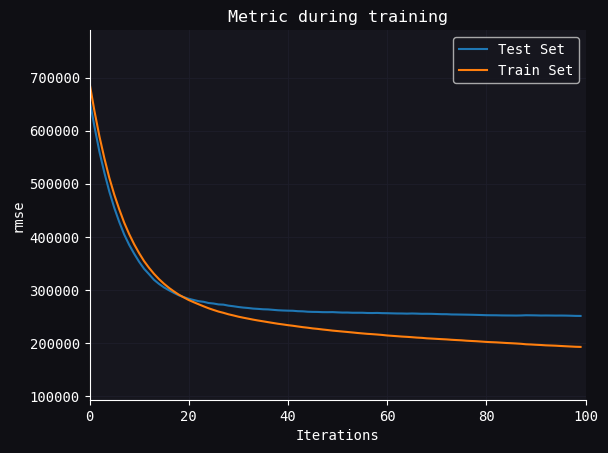

In [644]:
lgb.plot_metric(
    best_model_non_log, 
    dataset_names=['Test Set', 'Train Set'] )

<Axes: title={'center': 'Metric during training'}, xlabel='Iterations', ylabel='rmse'>

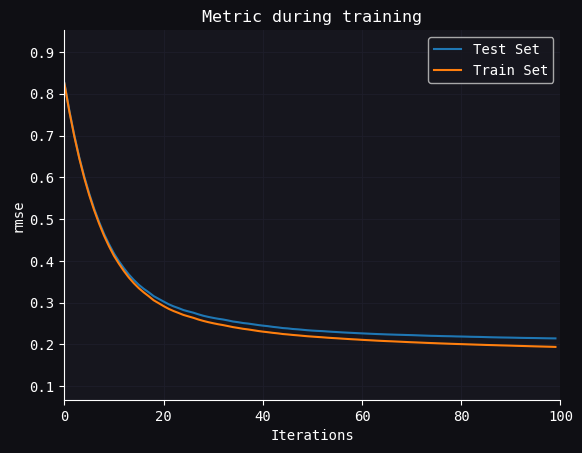

In [641]:
lgb.plot_metric(best_model_with_log, dataset_names=['Test Set', 'Train Set'] )

## 4.3 Statistical comparison — paired t-test on CV folds

Cross-validated means tell us *which* model has the lowest RMSE on
average, but not whether the difference is statistically meaningful or
within fold-to-fold noise. A paired t-test on per-fold RMSE answers exactly
that: are the per-fold differences between two models significantly
different from zero?

The cell below re-runs 10-fold CV with **identical splits** across all
four candidates (same `KFold(random_state=42)`).

1. Reports per-fold MAE in euros for each model.
2. Runs pairwise `scipy.stats.ttest_rel` for all six model pairs.
3. Plots the per-fold MAE distribution (box + strip) so the spread and
   overlap are visible.


Per-fold RMSE
   DecisionTree  RandomForest   XGBoost  LightGBM
0      324297.0      254424.0  255646.0  263256.0
1      295235.0      231307.0  237671.0  256237.0
2      333060.0      264329.0  250175.0  275758.0
3      286062.0      226434.0  237362.0  231404.0
4      465882.0      299119.0  283594.0  306253.0
5      339058.0      300567.0  301512.0  296955.0
6      368231.0      236106.0  234894.0  225603.0
7      390707.0      291472.0  281671.0  286540.0
8      332507.0      240641.0  240086.0  231569.0
9      301278.0      228420.0  226172.0  223974.0

Summary (€):
                  mean      std
DecisionTree  343632.0  53590.0
RandomForest  257282.0  29880.0
XGBoost       254878.0  25353.0
LightGBM      259755.0  30892.0

Pairwise paired t-tests (two-sided, paired by fold)
────────────────────────────────────────────────────────────────────────────
  DecisionTree  vs RandomForest    Δ=€  +86,350   t= +7.18   p=0.0001   winner: RandomForest  ***
  DecisionTree  vs XGBoost        

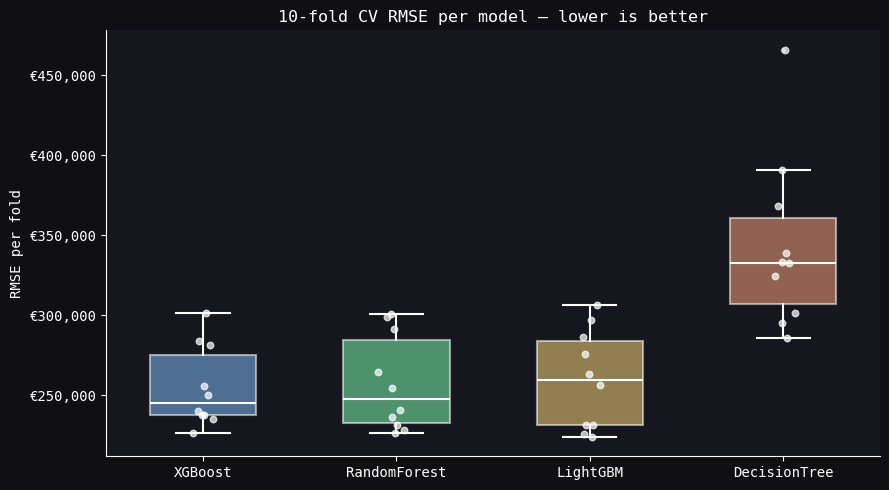


Saved → fig_model_comparison_paired_ttest.png


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re as _re
from scipy import stats
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb


scorer = make_scorer(rmse_euros, greater_is_better=False)

X_cmp = X_train.rename(
    columns=lambda c: _re.sub(r"[^A-Za-z0-9_]+", "", c)
)

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

models = {
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42, n_jobs=-1),
    "XGBoost":      xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    "LightGBM":     lgb.LGBMRegressor(random_state=42, force_row_wise=True,
                                      verbose=-1),
}

fold_rmse = {}
for name, model in models.items():
    res = cross_validate(model, X_cmp, y_train,
                         scoring=scorer, cv=kfold, n_jobs=-1)
    fold_rmse[name] = -res["test_score"]

rmse_df = pd.DataFrame(fold_rmse)
print("Per-fold RMSE")
print(rmse_df.round(0).to_string())
print()
print("Summary (€):")
print(rmse_df.agg(["mean", "std"]).round(0).T.to_string())
print()


print("Pairwise paired t-tests (two-sided, paired by fold)")
print("─" * 76)
names = list(fold_rmse)
for i, a in enumerate(names):
    for b in names[i + 1:]:
        t, p = stats.ttest_rel(fold_rmse[a], fold_rmse[b])
        d = fold_rmse[a].mean() - fold_rmse[b].mean()
        sig = ("***" if p < 0.001 else
               "**"  if p < 0.01  else
               "*"   if p < 0.05  else "ns")
        winner = a if d < 0 else b
        print(f"  {a:13s} vs {b:13s}   "
              f"Δ=€{d:+9,.0f}   t={t:+6.2f}   "
              f"p={p:.4f}   winner: {winner:13s} {sig}")


order = rmse_df.mean().sort_values().index.tolist()
data = [rmse_df[c].values for c in order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    data, labels=order, patch_artist=True, widths=0.55,
    medianprops=dict(color="#ffffff", lw=1.5),
    boxprops=dict(color="#ffffff", linewidth=1.5),      
    whiskerprops=dict(color="#ffffff", linewidth=1.5),  
    capprops=dict(color="#ffffff", linewidth=1.5),      
    flierprops=dict(marker="o", markersize=3, alpha=0.4, 
                    markerfacecolor="#ffffff", markeredgecolor="#ffffff"),
)

colors = [ACCENT, ACCENT3, "#f7d77e", ACCENT2]  
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.55)

rng = np.random.default_rng(0)
for i, vals in enumerate(data, start=1):
    ax.scatter(rng.normal(i, 0.04, len(vals)), vals,
               color="#ffffff", alpha=0.7, s=22, zorder=3)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"€{x:,.0f}")
)
ax.set_ylabel("RMSE per fold")
ax.set_title("10-fold CV RMSE per model — lower is better")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_model_comparison_paired_ttest.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → fig_model_comparison_paired_ttest.png")


## Manual comparison of performance results

In [ ]:
import numpy as np
from scipy import stats
import pandas as pd


results = {
    "RandomForest": {"R2": 0.940, "MAE": 110815, "MedAE": 37938, "RMSE": 255820, "MAPE": 16.15},
    "XGBoost":      {"R2": 0.946, "MAE": 111465, "MedAE": 40210, "RMSE": 249491, "MAPE": 15.82},
    "LightGBM":     {"R2": 0.945, "MAE": 104956, "MedAE": 36086, "RMSE": 237751, "MAPE": 14.58},
}

metrics_to_test = ["RMSE", "MAE", "MedAE"]

print("Pairwise Paired t-tests (two-sided)")
print("="*80)
print("\nNote: These are single-point comparisons (one test set), not true paired tests.")
print("Statistical significance cannot be reliably assessed from a single observation.\n")

models = list(results.keys())
for i, m1 in enumerate(models):
    for m2 in models[i+1:]:
        for metric in metrics_to_test:
            val1 = results[m1][metric]
            val2 = results[m2][metric]
            diff = val1 - val2
            
            # Direction: lower is better for RMSE/MAE/MedAE
            if diff < 0:
                winner = m1
            else:
                winner = m2
            
            print(f"{m1:15s} vs {m2:15s}  ({metric})")
            print(f"  {m1}: €{val1:>10,.0f}")
            print(f"  {m2}: €{val2:>10,.0f}")
            print(f"  Difference: €{abs(diff):>10,.0f}  →  Winner: {winner}")
            print()

# Summary table
print("\n" + "="*80)
print("SUMMARY TABLE — Final Test Set Performance")
print("="*80)
df_results = pd.DataFrame(results).T
print(df_results.to_string())

Pairwise Paired t-tests (two-sided)

Note: These are single-point comparisons (one test set), not true paired tests.
Statistical significance cannot be reliably assessed from a single observation.

RandomForest    vs XGBoost          (RMSE)
  RandomForest: €   255,820
  XGBoost: €   249,491
  Difference: €     6,329  →  Winner: XGBoost

RandomForest    vs XGBoost          (MAE)
  RandomForest: €   110,815
  XGBoost: €   111,465
  Difference: €       650  →  Winner: RandomForest

RandomForest    vs XGBoost          (MedAE)
  RandomForest: €    37,938
  XGBoost: €    40,210
  Difference: €     2,272  →  Winner: RandomForest

RandomForest    vs LightGBM         (RMSE)
  RandomForest: €   255,820
  LightGBM: €   237,751
  Difference: €    18,069  →  Winner: LightGBM

RandomForest    vs LightGBM         (MAE)
  RandomForest: €   110,815
  LightGBM: €   104,956
  Difference: €     5,859  →  Winner: LightGBM

RandomForest    vs LightGBM         (MedAE)
  RandomForest: €    37,938
  LightGBM: 

## 4.4 Model interpretation — PDP + SHAP

Two complementary views of the final model:

- **PDP** (Partial Dependence) — global marginal effect of one feature at a
  time: what does the model predict on average as that feature changes?
- **SHAP** — local per-sample contributions plus a global importance
  ranking by weight: how much does each feature contribute to *each
  individual* prediction?



Top 10 features by weight:
sq_mt_built       429
built_year        263
n_rooms           101
n_bathrooms        87
has_lift_True      80
district_id_5      80
district_id_15     59
district_id_20     58
district_id_13     56
district_id_3      55

Computing PDP …
Saved → fig1_pdp.png
Computing SHAP values (TreeExplainer — exact)…
SHAP values computed on 1000 test samples (subsampled)


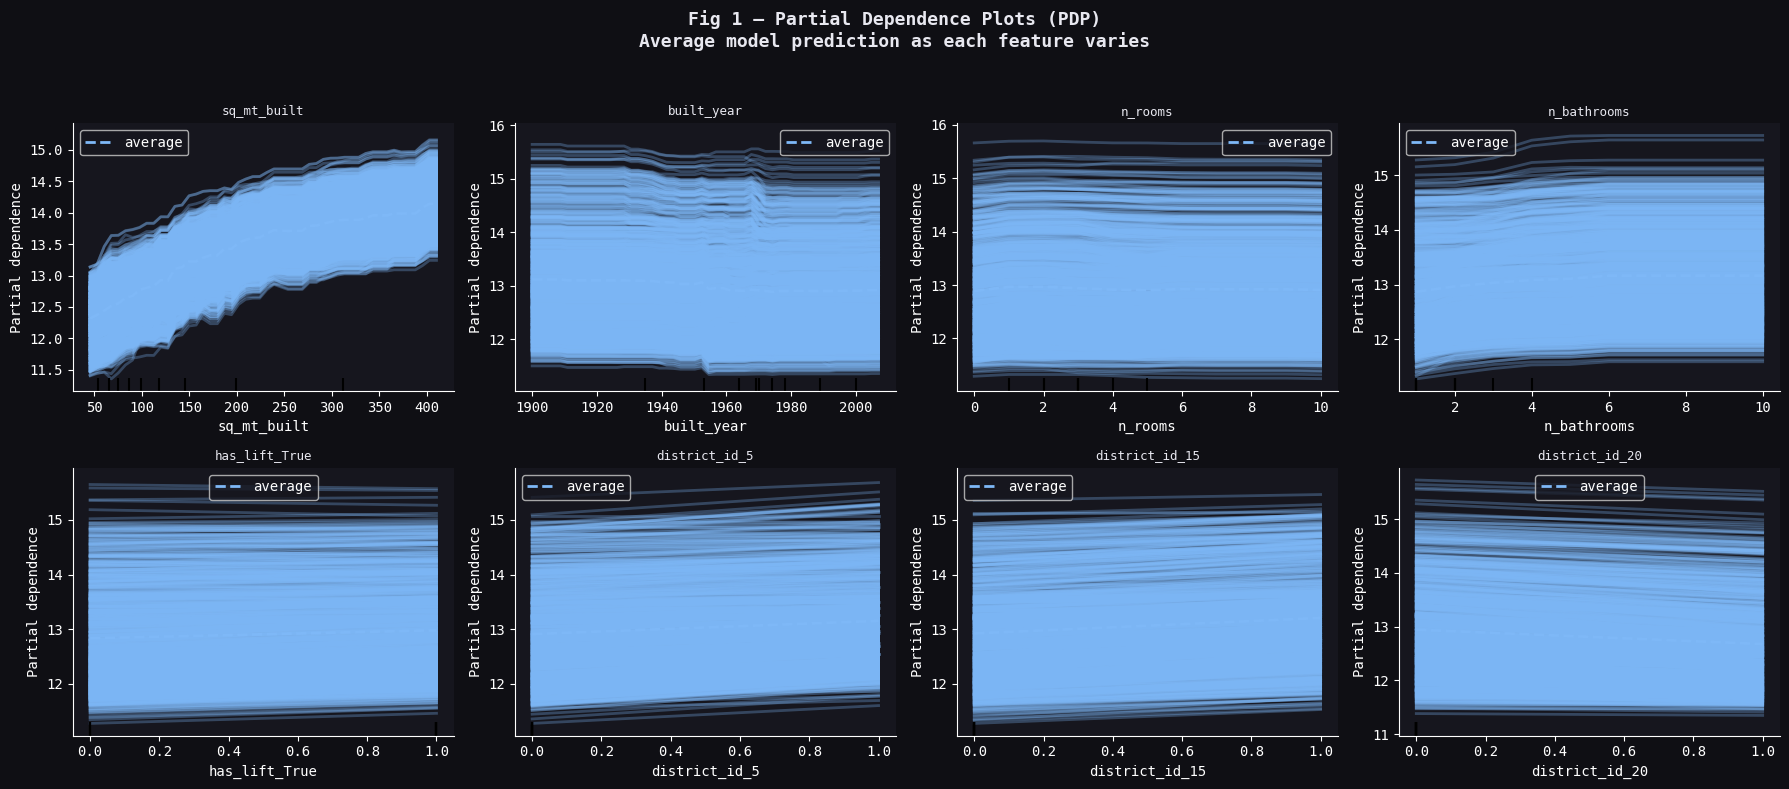

In [652]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import shap
from sklearn.inspection import PartialDependenceDisplay



importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns,
    name="weight"
).sort_values(ascending=False)

top_features = importances.head(10).index.tolist()
print("Top 10 features by weight:")
print(importances.head(10).to_string())


print("\nComputing PDP …")


sample_idx = np.random.default_rng(42).choice(
    len(X_train), size=min(2000, len(X_train)), replace=False
)
X_pdp = X_train.iloc[sample_idx]

n_features = min(8, len(top_features))
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig1, axes1 = plt.subplots(nrows, ncols,
                            figsize=(18, nrows * 4),
                            facecolor="#0f0f14")
fig1.suptitle("Fig 1 — Partial Dependence Plots (PDP)\n"
              "Average model prediction as each feature varies",
              fontsize=13, fontweight="bold", color="#e8e8f0")

for i, feature in enumerate(top_features[:n_features]):
    ax = axes1.flat[i]
    ax.set_facecolor("#16161e")

    disp = PartialDependenceDisplay.from_estimator(
        best_model, X_pdp,
        features       = [feature],
        kind           = "both",      # pure PDP (not ICE)
        grid_resolution= 50,
        ax             = ax,
        line_kw        = {"color": "#7eb8f7", "lw": 2},
    )

    yticks = ax.get_yticks()
    ax.set_yticklabels(
        [f"€{np.expm1(v)/1e3:.0f}k" for v in yticks], fontsize=7
    )
    ax.set_title(feature, fontsize=9, color="#e8e8f0")
    ax.set_xlabel(feature, fontsize=8)
    ax.set_ylabel("Avg prediction", fontsize=8)
    ax.grid(True, axis="y")

for j in range(n_features, len(axes1.flat)):
    axes1.flat[j].set_visible(False)

fig1.tight_layout(rect=[0, 0, 1, 0.95])
fig1.savefig("fig1_pdp.png", dpi=150, bbox_inches="tight",
             facecolor=fig1.get_facecolor())
print("Saved → fig1_pdp.png")

print("Computing SHAP values (TreeExplainer — exact)…")

subsample_idx = np.random.choice(len(X_test), min(1000, len(X_test)), replace=False)
X_test_sub = X_test.iloc[subsample_idx]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sub)  

print(f"SHAP values computed on {len(X_test_sub)} test samples (subsampled)")

In [525]:
X_train.head()

,sq_mt_built,n_rooms,n_bathrooms,is_exact_address_hidden,is_renewal_needed,built_year,has_parking,addr_has_number,addr_number_bucket,subtitle_Abrantes_Madrid,...,addr_street_type_Calle,addr_street_type_Camino,addr_street_type_Carretera,addr_street_type_Cuesta,addr_street_type_Glorieta,addr_street_type_Other,addr_street_type_Paseo,addr_street_type_Plaza,addr_street_type_Ronda,addr_street_type_Traves_a
1947,78.0,3,1.0,True,False,1960.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
21382,169.0,3,2.0,True,False,2000.0,True,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0
2225,30.0,0,1.0,True,False,1978.0,True,0,0.0,0,...,1,0,0,0,0,0,0,0,0,0
5201,74.0,3,1.0,False,False,1975.0,False,1,2.0,0,...,1,0,0,0,0,0,0,0,0,0
15566,180.0,3,3.0,True,False,2001.0,False,0,0.0,0,...,0,0,0,0,0,1,0,0,0,0


Saved → fig2a_shap_beeswarm.png
Saved → fig2b_shap_importance.png
Saved → fig2c_shap_dependence.png


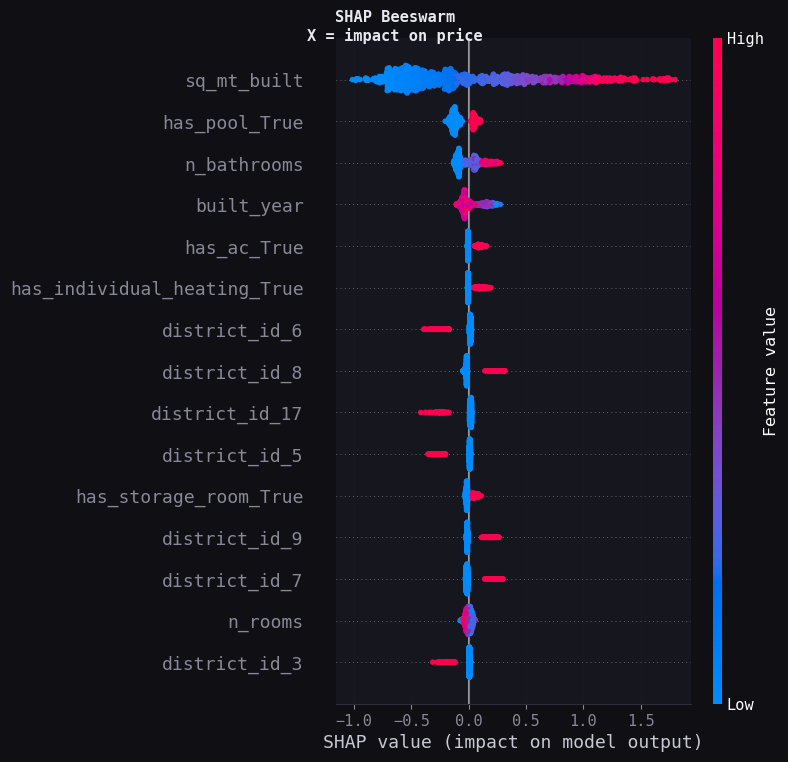

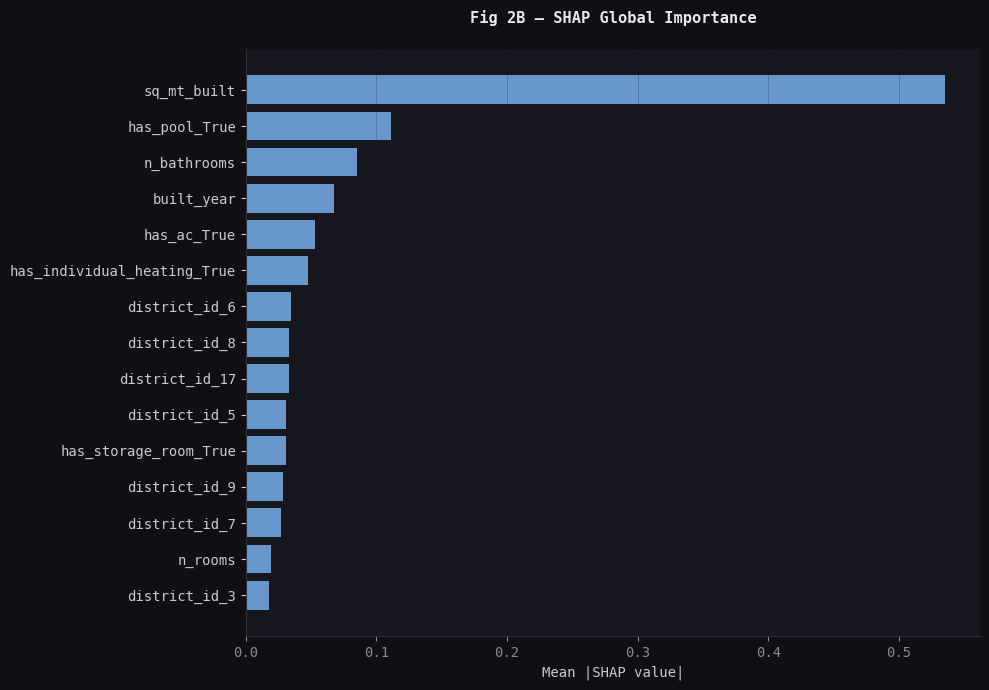

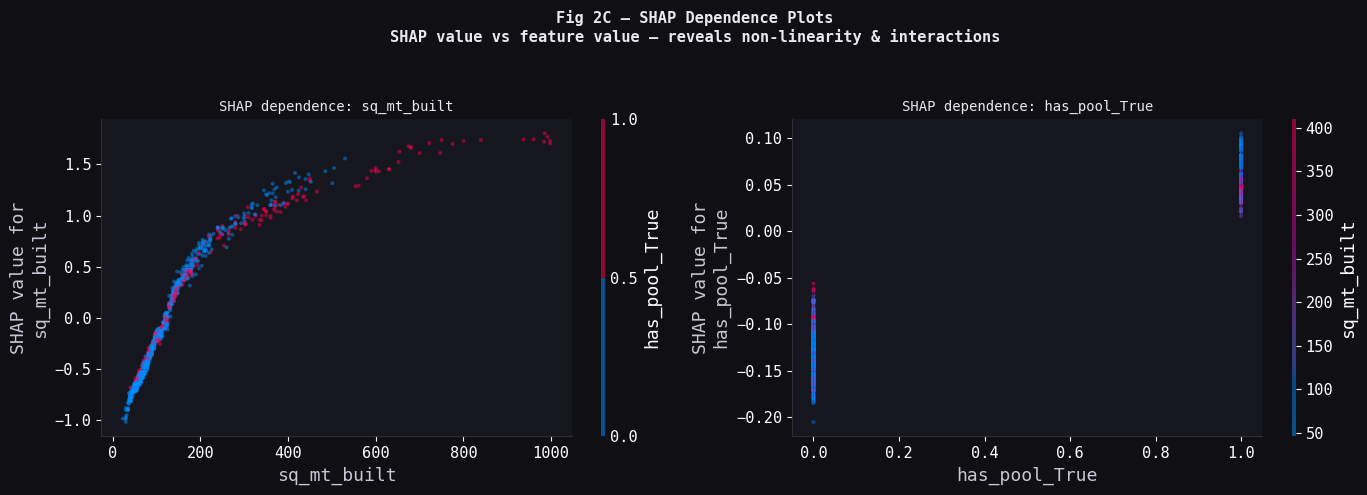

In [653]:
fig2a, ax2a = plt.subplots(figsize=(11, 8), facecolor="#0f0f14")
ax2a.set_facecolor("#16161e")
ax2a.tick_params(axis='y', colors="#c8c8d4")
ax2a.tick_params(axis='x', colors="#888899")

shap.summary_plot(
    shap_values, X_test_sub,
    max_display = 15,
    show        = False,
    plot_type   = "dot",
)

fig2a = plt.gcf()
fig2a.set_facecolor("#0f0f14")
fig2a.axes[0].set_facecolor("#16161e")
fig2a.axes[0].tick_params(colors="#888899")  # ← add x-axis styling
fig2a.axes[0].xaxis.label.set_color("#c8c8d4")  # ← x-axis label
fig2a.axes[0].spines['bottom'].set_color("#2e2e3a")  # ← axis border
fig2a.axes[0].spines['left'].set_color("#2e2e3a")
fig2a.axes[0].grid(True, color="#1e1e2a", alpha=0.3)  # ← grid color

fig2a.suptitle("SHAP Beeswarm\n"
               "X = impact on price",
               fontsize=11, fontweight="bold", color="#e8e8f0", y=1.01)

fig2a.savefig("fig2a_shap_beeswarm.png", dpi=150, bbox_inches="tight",
              facecolor="#0f0f14")
print("Saved → fig2a_shap_beeswarm.png")

# ── Fig 2B: SHAP bar ──────────────────────────────────────────────────────────
fig2b, ax2b = plt.subplots(figsize=(10, 7), facecolor="#0f0f14")
ax2b.set_facecolor("#16161e")

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=True).tail(15)

bars = ax2b.barh(mean_shap.index, mean_shap.values,
                 color="#7eb8f7", alpha=0.8, edgecolor="none")

ax2b.set_xlabel("Mean |SHAP value|", color="#c8c8d4")  # ← label color
ax2b.tick_params(axis='y', colors="#c8c8d4")  # ← feature names
ax2b.tick_params(axis='x', colors="#888899")  # ← values
ax2b.spines['bottom'].set_color("#2e2e3a")
ax2b.spines['left'].set_color("#2e2e3a")
ax2b.grid(True, axis="x", color="#1e1e2a", alpha=0.3)  # ← grid color

ax2b.set_title("Fig 2B — SHAP Global Importance\n",
               fontsize=11, fontweight="bold", color="#e8e8f0")

fig2b.tight_layout()
fig2b.savefig("fig2b_shap_importance.png", dpi=150, bbox_inches="tight",
              facecolor=fig2b.get_facecolor())
print("Saved → fig2b_shap_importance.png")

# ── Fig 2C: SHAP dependence ───────────────────────────────────────────────────
top1 = mean_shap.index[-1]
top2 = mean_shap.index[-2]

fig2c, axes2c = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0f0f14")
fig2c.suptitle("Fig 2C — SHAP Dependence Plots\n"
               "SHAP value vs feature value — reveals non-linearity & interactions",
               fontsize=11, fontweight="bold", color="#e8e8f0")

for ax, feat in zip(axes2c, [top1, top2]):
    ax.set_facecolor("#16161e")
    
    shap.dependence_plot(
        feat, shap_values, X_test_sub,
        ax       = ax,
        show     = False,
        dot_size = 8,
        alpha    = 0.5,
    )
    
    # Apply theme after SHAP plot
    ax.set_facecolor("#16161e")
    ax.tick_params(colors="#FFFFFF")  # ← all ticks
    ax.xaxis.label.set_color("#c8c8d4")  # ← x-label
    ax.yaxis.label.set_color("#c8c8d4")  # ← y-label
    ax.spines['bottom'].set_color("#2e2e3a")
    ax.spines['left'].set_color("#2e2e3a")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.set_title(f"SHAP dependence: {feat}", fontsize=10, color="#e8e8f0")
    ax.grid(True, color="#1e1e2a", alpha=0.3)

fig2c.tight_layout(rect=[0, 0, 1, 0.93])
fig2c.savefig("fig2c_shap_dependence.png", dpi=150, bbox_inches="tight",
              facecolor=fig2c.get_facecolor())
print("Saved → fig2c_shap_dependence.png")

plt.show()

In [673]:
X_train_num_cleaned = clean_feature_names(X_train_num)

vanilla_lgbm_num = lgb.LGBMRegressor(objective="rmse")

vanilla_lgbm_num.fit(X_train_num_cleaned, np.expm1x(y_train))

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,'rmse'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


PermutationExplainer explainer: 501it [00:29, 11.04it/s]                         


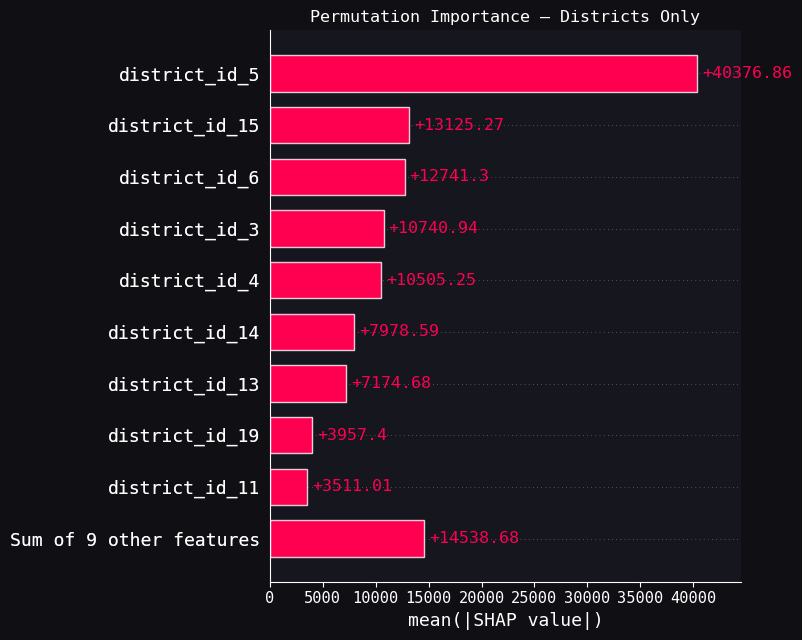

In [ ]:
import shap

masker = shap.maskers.Independent(X_test_num, max_samples=100)


explainer = shap.PermutationExplainer(
    model=vanilla_lgbm_num.predict,
    masker=masker,  
    feature_names=X_test_num.columns,
)


shap_values = explainer(X_test_num.iloc[:500])  


district_cols = [c for c in X_test.columns if 'district_id_' in c]
district_indices = [i for i, col in enumerate(X_test.columns) if col in district_cols]

shap_values_districts = shap_values[:, district_indices]
shap_values_districts.feature_names = district_cols

# Plot
shap.plots.bar(shap_values_districts, show=False)
plt.title("Permutation Importance — Districts Only")
plt.tight_layout()
plt.savefig("perm_importance_districts_shap.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Final Model safing for faster runs in the future

In [ ]:
import joblib

joblib.dump(best_model, 'best_lgbm.pkl')